In [1]:
# read the data
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd
import matplotlib
import pandas as pd
import mne
import os
from mne.preprocessing import ICA

In [2]:
## Some of the common function 
def identify_bad_channels(data, threshold=80e-6):
    """
    Identify bad channels based on amplitude difference exceeding the threshold.
    
    :param data: 3D array of shape (n_epochs, n_channels, n_times)
    :param threshold: Amplitude difference threshold in Volts (default: 80 microvolts)
    :return: List of bad channel indices
    """
    amplitude_diff = np.ptp(data, axis=2)  # peak-to-peak amplitude for each epoch and channel
    bad_channels = np.where(np.any(amplitude_diff > threshold, axis=0))[0]
    return bad_channels.tolist()


def remove_epochs_with_bad_mmn_channels(epochs, mmn_channels, amplitude_threshold=80e-6):
    """
    Remove epochs where MMN-related channels exceed the amplitude threshold.
    
    :param epochs: mne.Epochs object
    :param mmn_channels: List of MMN channel names
    :param amplitude_threshold: Amplitude difference threshold in Volts (default: 80 microvolts)
    :return: mne.Epochs object with bad epochs removed
    """
    data = epochs.get_data()
    
    
    bad_mmn_epochs = []
    for epoch_idx in range(len(epochs)):
        epoch_data = data[epoch_idx]
        epoch_bad_channels = identify_bad_channels(epoch_data[np.newaxis, :, :], amplitude_threshold)
        
        for ch_idx in epoch_bad_channels:
            ch_name = epochs.ch_names[ch_idx]
            if any(mmn_ch in ch_name for mmn_ch in mmn_channels):
                bad_mmn_epochs.append(epoch_idx)
                break
    
    good_epochs = np.setdiff1d(np.arange(len(epochs)), bad_mmn_epochs)
    return epochs[good_epochs]


## Different Groups 

In [ ]:
subject_info= pd.read_excel(r"E:\ecf-exp2-notif-mmn\data\Processed\Participant_details.xlsx")
subject_info.head()

In [4]:
"""PG_sub = subject_info["Subject Id"][subject_info['profession'].str.contains("PG")]
PG_sub_D = [pg  for pg in list(PG_sub) if 'SD' in str(pg)]
UG_sub = subject_info["Subject Id"][subject_info['profession'].str.contains("UG")]
UG_sub_D = [ug  for ug in list(UG_sub) if 'SD' in str(ug)] 
non_sub = subject_info["Subject Id"][subject_info['profession'].str.contains("non")]
non_sub_D = [non  for non in list(non_sub) if 'SD' in str(non)] 
print("PG academic:-- no. of subject ", len(PG_sub_D), " subjects ID ", PG_sub_D)
print("UG academic:-- no. of subject ", len(UG_sub_D), " subjects ID ", UG_sub_D)
print("Non academic:-- no. of subject ", len(non_sub_D), " subjects ID ", non_sub_D)"""

'PG_sub = subject_info["Subject Id"][subject_info[\'profession\'].str.contains("PG")]\nPG_sub_D = [pg  for pg in list(PG_sub) if \'SD\' in str(pg)]\nUG_sub = subject_info["Subject Id"][subject_info[\'profession\'].str.contains("UG")]\nUG_sub_D = [ug  for ug in list(UG_sub) if \'SD\' in str(ug)] \nnon_sub = subject_info["Subject Id"][subject_info[\'profession\'].str.contains("non")]\nnon_sub_D = [non  for non in list(non_sub) if \'SD\' in str(non)] \nprint("PG academic:-- no. of subject ", len(PG_sub_D), " subjects ID ", PG_sub_D)\nprint("UG academic:-- no. of subject ", len(UG_sub_D), " subjects ID ", UG_sub_D)\nprint("Non academic:-- no. of subject ", len(non_sub_D), " subjects ID ", non_sub_D)'

In [ ]:
subject_info["avg_S"] = subject_info[['MPPUS score',	'SAS score'	]].mean(axis=1)
subject_info_D=subject_info[subject_info["Subject Id"].str.contains("SD")]
subject_info_D

Shapiro-Wilk Test for MPPUS: ShapiroResult(statistic=0.9817889115117645, pvalue=0.8708649952198713)
Shapiro-Wilk Test for SAS: ShapiroResult(statistic=0.9846688739799122, pvalue=0.9314182444998721)
Shapiro-Wilk Test for Avg: ShapiroResult(statistic=0.9749843531704555, pvalue=0.682268109657202)


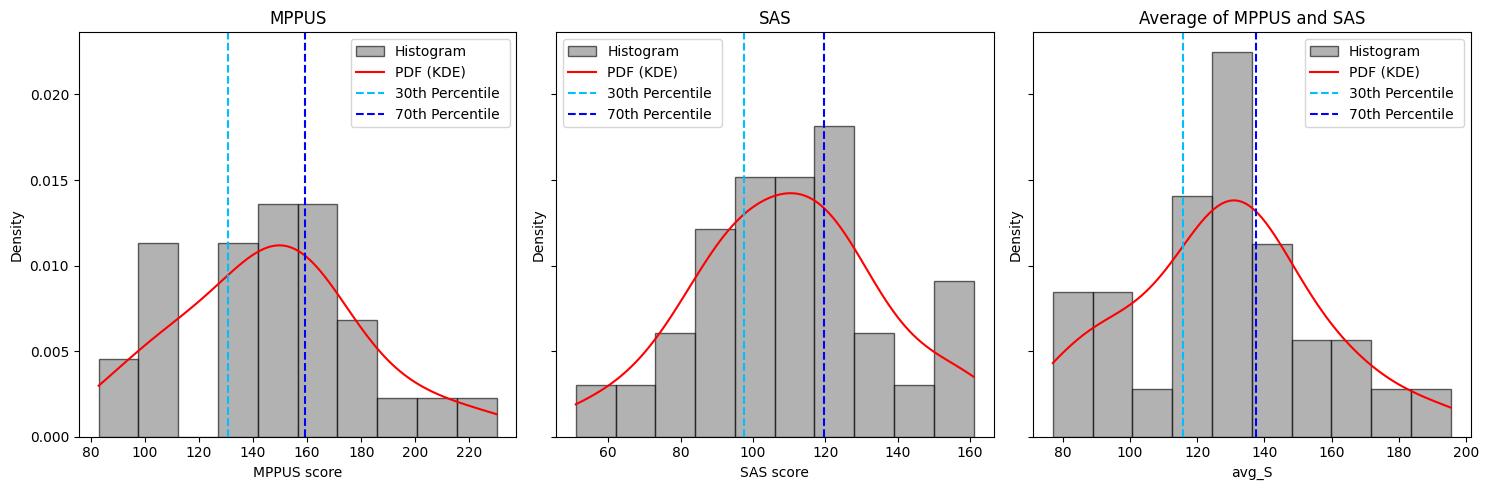

In [6]:
from scipy.stats import shapiro, kstest
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
# Shapiro-Wilk test
shapiro_mppus = shapiro(subject_info_D['MPPUS score'])
shapiro_sas = shapiro(subject_info_D['SAS score'])
shapiro_avg_s = shapiro(subject_info_D['avg_S'])
print("Shapiro-Wilk Test for MPPUS:", shapiro_mppus)
print("Shapiro-Wilk Test for SAS:", shapiro_sas)
print("Shapiro-Wilk Test for Avg:", shapiro_avg_s )




# Set up the figure for subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
columns = ['MPPUS score',	'SAS score', 'avg_S']
titles = ['MPPUS', 'SAS', 'Average of MPPUS and SAS']

# Loop through columns to plot
for ax, column, title in zip(axes, columns, titles):
    # Data for the column
    data = subject_info_D[column]
    # Calculate quantiles
    q1 = subject_info_D[column].quantile(0.30)  # 25th percentil
    q3 = subject_info_D[column].quantile(0.70)  # 75th percentile
    # Plot histogram with density=True (normalized to PDF)
    ax.hist(data, bins=10, density=True, alpha=0.6, color='grey',edgecolor='black', label='Histogram')
    
    # Add Gaussian KDE for smooth curve
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 100)
    ax.plot(x_vals, kde(x_vals), color='red', label='PDF (KDE)')
    ax.axvline(q1, color='deepskyblue', linestyle='--', label='30th Percentile ')
    ax.axvline(q3, color='blue', linestyle='--', label='70th Percentile ')
    # Formatting
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel('Density')
    ax.legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

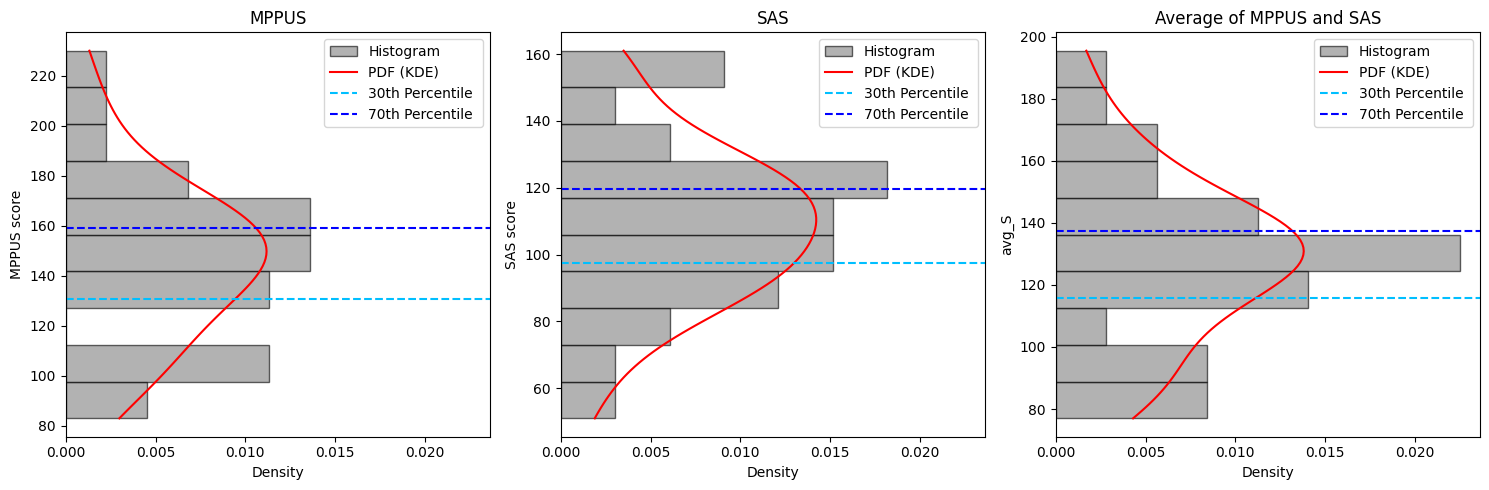

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex = True)
columns = ['MPPUS score',	'SAS score', 'avg_S']
titles = ['MPPUS', 'SAS', 'Average of MPPUS and SAS']
for ax, column, title in zip(axes, columns, titles):
    # Data for the column
    data = subject_info_D[column]
    # Calculate quantiles
    q1 = subject_info_D[column].quantile(0.30)  # 25th percentil
    q3 = subject_info_D[column].quantile(0.70)  # 75th percentile
    # Plot horizontal histogram with density=True
    ax.hist(data, bins=10, density=True, alpha=0.6, color='grey',orientation='horizontal',edgecolor='black', label='Histogram')
    
    # Add Gaussian KDE for smooth curve
    kde = gaussian_kde(data)
    y_vals = np.linspace(data.min(), data.max(), 100)
    ax.plot(kde(y_vals), y_vals, color='red', label='PDF (KDE)')
    ax.axhline(q1, color='deepskyblue', linestyle='--', label='30th Percentile ')
    ax.axhline(q3, color='blue', linestyle='--', label='70th Percentile ')
    # Formatting
    ax.set_title(title)
    ax.set_ylabel(column)
    ax.set_xlabel('Density')
    ax.legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

1 Spine
0 Spine


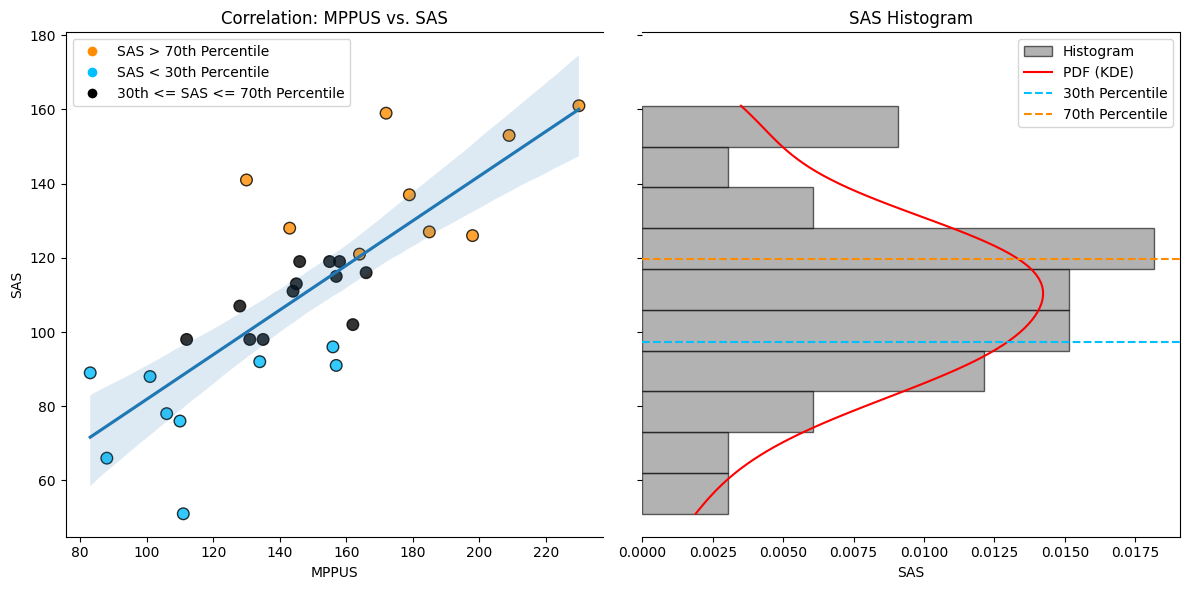

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Calculate 30th and 70th percentiles for SAS
sas_30 = subject_info_D['SAS score'].quantile(0.30) 
sas_70 = subject_info_D['SAS score'].quantile(0.70) 

# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)  # Share y-axis for alignment
scatter_ax, hist_ax = axes

# === First subplot: Correlation Scatter Plot === #
# Color code based on SAS percentiles
colors = np.where(subject_info_D['SAS score'] >= sas_70, 'darkorange', 
                  np.where(subject_info_D['SAS score'] <= sas_30,'deepskyblue', 'black'))
colors = colors.tolist()
# Scatter plot
#scatter_ax.scatter(subject_info_D['MPPUS score'], subject_info_D['SAS score'], c=colors, alpha=0.8, edgecolor='k', s=70)
# Scatter plot with regression line (on the right subplot)
sns.regplot(x = subject_info_D['MPPUS score'], y= subject_info_D['SAS score'], ax=scatter_ax,
            scatter_kws={"color": colors, "s": 70, "edgecolor": "black"}  )
scatter_ax.set_title('Correlation: MPPUS vs. SAS')
scatter_ax.set_xlabel('MPPUS')
scatter_ax.set_ylabel('SAS')

# Add legend
scatter_ax.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=8, label='SAS > 70th Percentile'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='deepskyblue', markersize=8, label='SAS < 30th Percentile'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=8, label='30th <= SAS <= 70th Percentile'),
], loc='upper left')
# === Second subplot: SAS Histogram === #
hist_ax.hist(subject_info_D['SAS score'], bins=10, alpha=0.6,  color='grey',orientation='horizontal',edgecolor='black', label='Histogram',density=True)
# Add Gaussian KDE for smooth curve
kde = gaussian_kde(subject_info_D['SAS score'])
y_vals = np.linspace(subject_info_D['SAS score'].min(), subject_info_D['SAS score'].max(), 100)
hist_ax.plot(kde(y_vals), y_vals, color='red', label='PDF (KDE)')
hist_ax.axhline(sas_30, color='deepskyblue', linestyle='--', label='30th Percentile')
hist_ax.axhline(sas_70, color='darkorange', linestyle='--', label='70th Percentile')

hist_ax.set_title('SAS Histogram')
hist_ax.set_xlabel('SAS')
hist_ax.legend()
# Remove space between plots
for s,spine in enumerate(axes[0].spines.values()):
    if s ==1 :
        print(s,spine)
        spine.set_visible(False)
# Remove space between plots
for s,spine in enumerate(axes[1].spines.values()):
    if s ==0 :
        print(s,spine)
        spine.set_visible(False)
plt.subplots_adjust(wspace=0.0)
# Adjust layout and show plot
plt.tight_layout()
plt.show()


In [ ]:
subject_info_D['MPPUS score'].median()
subject_info_D['SAS score'].median()
subject_info_D_low = subject_info_D[subject_info_D['SAS score']<=subject_info_D['SAS score'].quantile(.30)]
subject_info_D_low

In [10]:
subject_info_D['SAS score'].quantile(.70)

119.6

In [ ]:
subject_info_D_high = subject_info_D[subject_info_D['SAS score']>=subject_info_D['SAS score'].quantile(.70)]
subject_info_D_high

In [ ]:
#subject_info_D_med = subject_info_D[subject_info_D['avg_S']>=subject_info_D['avg_S'].quantile(.70)]
subject_info_D_med  = subject_info_D[(subject_info_D['SAS score']<subject_info_D['SAS score'].quantile(.70)) & (subject_info_D['SAS score']>subject_info_D['SAS score'].quantile(.30))]
subject_info_D_med

In [ ]:
list(subject_info_D_med['Subject Id'])

# low vs high smartphone smartphone users

### Block 1 MMN calculation

In [ ]:

data_folder = r"D:\Work_data\Notification_evoked_response\Data_at_IITD/"
subjects = os.listdir(data_folder)
data_type = "EEG"
# catogory subject list 
low_sub_D = list(subject_info_D_low['Subject Id'])
med_sub_D = list(subject_info_D_med['Subject Id'])
high_sub_D = list(subject_info_D_high['Subject Id'])
# Create an empty list to hold epochs from all subjects
#B1_sta_all_epochs_list =[]
#B1_devi_all_epochs_list = []
low_sub_D_B1_all_epochs_list =[]
med_sub_D_B1_all_epochs_list =[]
high_sub_D_B1_all_epochs_list =[]
for sub in os.listdir(data_folder):
    path = os.path.join(data_folder,sub,data_type)
    
    for eeg in os.listdir(path):
        if eeg[-5:] == ".vhdr":
           
            raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
            raw = mne.add_reference_channels(raw, ref_channels=["Cz"])
            raw.set_montage("easycap-M1")
            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )
            # Now re-reference the data :-n average reference 
            #raw.set_eeg_reference('average')
            raw.set_eeg_reference(ref_channels=['TP9', 'TP10'])
            # filter 
            raw.filter(l_freq=0.1,h_freq=30)
            events,event_dict = mne.events_from_annotations(raw)
            epochs_with_eog = mne.Epochs(raw, events, event_id=[14,15,24,25] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=False,
                    preload=True)
            print(f"Original number of epochs in Block 1  {len(epochs_with_eog['14','15'])} and in Block 2 {len(epochs_with_eog['24','25'])}")
            
            # EOG detection and epoch rejection
            eog_channels = ['Fp1', 'Fp2', 'F7', 'F8',"AF7",'AF8']  # Adjust these to match your channel names
            
            eog_events = mne.preprocessing.find_eog_events(raw,ch_name=eog_channels)
            onsets = eog_events[:, 0] / raw.info["sfreq"] - 0.25
            durations = [0.5] * len(eog_events)
            descriptions = ["bad blink"] * len(eog_events)
            blink_annot = mne.Annotations(
                onsets, durations, descriptions, orig_time=raw.info["meas_date"]
                )
            raw.set_annotations(blink_annot)
            #raw.plot(events =events , scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )
            # Create Epochs
            epochs = mne.Epochs(raw, events, event_id=[14,15,24,25] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)
            
            print(f"After Eog rejection, number of epochs in Block 1  {len(epochs['14','15'])} and in Block 2 {len(epochs['24','25'])}")
            # Define your MMN channels
            mmn_channels =[ 'Fz', 'Cz','Pz']  # Example MMN channels, adjust as needed
            # Remove epochs with bad MMN channels
            cleaned_epochs = remove_epochs_with_bad_mmn_channels(epochs, mmn_channels)
            # Append the subject's epochs to the list
            if sub in low_sub_D:
                low_sub_D_B1_all_epochs_list.append(cleaned_epochs['14','15'])
            elif sub in med_sub_D:
                med_sub_D_B1_all_epochs_list.append(cleaned_epochs['14','15'])
            elif sub in high_sub_D:
                high_sub_D_B1_all_epochs_list.append(cleaned_epochs['14','15'])
            else:
                print(sub ," is not available ")
            




low_sub_D_B1_all_epochs = mne.concatenate_epochs(low_sub_D_B1_all_epochs_list)
med_sub_D_B1_all_epochs = mne.concatenate_epochs(med_sub_D_B1_all_epochs_list)
high_sub_D_B1_all_epochs = mne.concatenate_epochs(high_sub_D_B1_all_epochs_list)

print(f"After Bad epoch rejection,  number of epochs in Block 1 in standard {len(low_sub_D_B1_all_epochs['14'])},{len(med_sub_D_B1_all_epochs['14'])} , {len(high_sub_D_B1_all_epochs['14'])}  and in deviant {len(low_sub_D_B1_all_epochs['15'])},{len(med_sub_D_B1_all_epochs['15'])} ,{len(high_sub_D_B1_all_epochs['15'])} for PG, UG and non-acadmeic, respectively ")

low_sub_D_B1_devi_eps = low_sub_D_B1_all_epochs['15'].average()
low_sub_D_B1_sta_eps = low_sub_D_B1_all_epochs["14"].average()
low_sub_D_B1_MMN_erp = mne.combine_evoked([low_sub_D_B1_devi_eps,low_sub_D_B1_sta_eps], weights=[1,-1])

med_sub_D_B1_devi_eps = med_sub_D_B1_all_epochs['15'].average()
med_sub_D_B1_sta_eps = med_sub_D_B1_all_epochs["14"].average()
med_sub_D_B1_MMN_erp = mne.combine_evoked([ med_sub_D_B1_devi_eps,med_sub_D_B1_sta_eps], weights=[1,-1])

high_sub_D_B1_devi_eps = high_sub_D_B1_all_epochs['15'].average()
high_sub_D_B1_sta_eps = high_sub_D_B1_all_epochs["14"].average()
high_sub_D_B1_MMN_erp = mne.combine_evoked([ high_sub_D_B1_devi_eps,high_sub_D_B1_sta_eps], weights=[1,-1])

In [ ]:
import mne
import matplotlib.pyplot as plt

# Assuming you have a dictionary of Evoked objects 'evokeds'
evokeds = {'Pers. deviant': low_sub_D_B1_devi_eps,
           'non. sign. standard': low_sub_D_B1_sta_eps,
           "B1 MMN" : low_sub_D_B1_MMN_erp,
           }


# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.61    # End of time window in seconds

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1,3,figsize=(27, 9))  # Create a figure and axis
picks  = ["Fz","Cz","Pz"]

stylesdict ={'Pers. deviant': {"linewidth": 2,"linestyle":'--'},
             'non. sign. standard': {"linewidth": 2,"linestyle":'--'},
             "B1 MMN": {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show = False)
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-4.2, 4.2]),
                                   truncate_xaxis=False,show= False)

fig.suptitle('Grand ERP for Block 1 of all Epochs for Low score', fontsize=20)
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size
    'legend.fontsize': 20,   # Legend font size
})
plt.show()

### Block 2 MMN calculation 

In [ ]:
del low_sub_D_B1_all_epochs
del low_sub_D_B1_all_epochs_list
del med_sub_D_B1_all_epochs
del med_sub_D_B1_all_epochs_list
del high_sub_D_B1_all_epochs
del high_sub_D_B1_all_epochs_list

data_folder = r"D:\Work_data\Notification_evoked_response\Data_at_IITD/"
subjects = os.listdir(data_folder)
data_type = "EEG"
# catogory subject list 
low_sub_D = list(subject_info_D_low['Subject Id'])
med_sub_D = list(subject_info_D_med['Subject Id'])
high_sub_D = list(subject_info_D_high['Subject Id'])
# Create an empty list to hold epochs from all subjects
#B1_sta_all_epochs_list =[]
#B1_devi_all_epochs_list = []
low_sub_D_B2_all_epochs_list =[]
med_sub_D_B2_all_epochs_list =[]
high_sub_D_B2_all_epochs_list =[]
for sub in os.listdir(data_folder):
    path = os.path.join(data_folder,sub,data_type)
    
    for eeg in os.listdir(path):
        if eeg[-5:] == ".vhdr":
           
            raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
            raw = mne.add_reference_channels(raw, ref_channels=["Cz"])
            raw.set_montage("easycap-M1")
            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )
            # Now re-reference the data :-n average reference 
            #raw.set_eeg_reference('average')
            raw.set_eeg_reference(ref_channels=['TP9', 'TP10'])
            # filter 
            raw.filter(l_freq=0.1,h_freq=30)
            events,event_dict = mne.events_from_annotations(raw)
            epochs_with_eog = mne.Epochs(raw, events, event_id=[14,15,24,25] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=False,
                    preload=True)
            print(f"Original number of epochs in Block 1  {len(epochs_with_eog['14','15'])} and in Block 2 {len(epochs_with_eog['24','25'])}")
            
            # EOG detection and epoch rejection
            eog_channels = ['Fp1', 'Fp2', 'F7', 'F8',"AF7",'AF8']  # Adjust these to match your channel names
            
            eog_events = mne.preprocessing.find_eog_events(raw,ch_name=eog_channels)
            onsets = eog_events[:, 0] / raw.info["sfreq"] - 0.25
            durations = [0.5] * len(eog_events)
            descriptions = ["bad blink"] * len(eog_events)
            blink_annot = mne.Annotations(
                onsets, durations, descriptions, orig_time=raw.info["meas_date"]
                )
            raw.set_annotations(blink_annot)
            #raw.plot(events =events , scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )
            # Create Epochs
            epochs = mne.Epochs(raw, events, event_id=[14,15,24,25] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)
            
            print(f"After Eog rejection, number of epochs in Block 1  {len(epochs['14','15'])} and in Block 2 {len(epochs['24','25'])}")
            # Define your MMN channels
            mmn_channels =[ 'Fz', 'Cz','Pz']  # Example MMN channels, adjust as needed
            # Remove epochs with bad MMN channels
            cleaned_epochs = remove_epochs_with_bad_mmn_channels(epochs, mmn_channels)
            # Append the subject's epochs to the list
            if sub in low_sub_D:
                low_sub_D_B2_all_epochs_list.append(cleaned_epochs['24','25'])
            elif sub in med_sub_D:
                med_sub_D_B2_all_epochs_list.append(cleaned_epochs['24','25'])
            elif sub in high_sub_D:
                high_sub_D_B2_all_epochs_list.append(cleaned_epochs['24','25'])
            else:
                print(sub ," is not available ")
            




low_sub_D_B2_all_epochs = mne.concatenate_epochs(low_sub_D_B2_all_epochs_list)
med_sub_D_B2_all_epochs = mne.concatenate_epochs(med_sub_D_B2_all_epochs_list)
high_sub_D_B2_all_epochs = mne.concatenate_epochs(high_sub_D_B2_all_epochs_list)

print(f"After Bad epoch rejection,  number of epochs in Block 1 in standard {len(low_sub_D_B2_all_epochs['24'])},{len(med_sub_D_B2_all_epochs['24'])} , {len(high_sub_D_B2_all_epochs['24'])}  and in deviant {len(low_sub_D_B2_all_epochs['25'])},{len(med_sub_D_B2_all_epochs['25'])} ,{len(high_sub_D_B2_all_epochs['25'])} for PG, UG and non-acadmeic, respectively ")

low_sub_D_B2_devi_eps = low_sub_D_B2_all_epochs['25'].average()
low_sub_D_B2_sta_eps = low_sub_D_B2_all_epochs["24"].average()
low_sub_D_B2_MMN_erp = mne.combine_evoked([low_sub_D_B2_devi_eps,low_sub_D_B2_sta_eps], weights=[1,-1])

med_sub_D_B2_devi_eps = med_sub_D_B2_all_epochs['25'].average()
med_sub_D_B2_sta_eps = med_sub_D_B2_all_epochs["24"].average()
med_sub_D_B2_MMN_erp = mne.combine_evoked([ med_sub_D_B2_devi_eps,med_sub_D_B2_sta_eps], weights=[1,-1])

high_sub_D_B2_devi_eps = high_sub_D_B2_all_epochs['25'].average()
high_sub_D_B2_sta_eps = high_sub_D_B2_all_epochs["24"].average()
high_sub_D_B2_MMN_erp = mne.combine_evoked([ high_sub_D_B2_devi_eps,high_sub_D_B2_sta_eps], weights=[1,-1])
"""
After Bad epoch rejection,  number of epochs in Block 1 in standard 3541,6230 , 3948  and in deviant 729,1303 ,784 for PG, UG and non-acadmeic, respectively 
"""

In [17]:
del low_sub_D_B2_all_epochs
del low_sub_D_B2_all_epochs_list
del med_sub_D_B2_all_epochs
del med_sub_D_B2_all_epochs_list
del high_sub_D_B2_all_epochs
del high_sub_D_B2_all_epochs_list


### Personailed audio related ERP

In [18]:
import ast
def get_latency_amp(evokeds,tmin, tmax,channels = picks):
    peak_data = {}
    for name, evoked in evokeds.items():
        evoked_fz = evoked.copy().pick(picks)
        # Retrieve the latency (time), amplitude, and channel where the peak occurs
        peak_channel, peak_time, peak_amplitude,  = evoked_fz.get_peak(ch_type='eeg', tmin=tmin, tmax=tmax, mode='neg', return_amplitude=True)
        peak_data[name] = {
            'Channel': peak_channel,  # channel where peak occurs
            'Latency (s)': peak_time,  # latency of peak
            'Amplitude (µV)': peak_amplitude  # amplitude of peak
            }
    return peak_data

def get_latency_amp_each_chn(evokeds,tmin, tmax,channels):
    peak_data = {}
    for name, evoked in evokeds.items():
        peak_data[name] = {}
        for ch in channels:
            evoked_fz = evoked.copy()
            evoked_fz =evoked_fz.pick([str(ch)])
            # Retrieve the latency (time), amplitude, and channel where the peak occurs
            try:
                peak_channel, peak_time_p, peak_amplitude_p,  = evoked_fz.get_peak(ch_type='eeg', tmin=tmin, tmax=tmax, mode='pos', return_amplitude=True)
                peak_data[name].update({str(ch) + ' +(Latency (s),Amplitude (µV))': str((peak_time_p, round( peak_amplitude_p*1e6,3)))})
            except:
                (peak_time_p, peak_amplitude_p)= ("Na", 'Na')
                peak_data[name].update({str(ch) + ' +(Latency (s),Amplitude (µV))': str((peak_time_p, peak_amplitude_p))}) 
            try:
                peak_channel, peak_time_n, peak_amplitude_n,  = evoked_fz.get_peak(ch_type='eeg', tmin=tmin, tmax=tmax, mode='neg', return_amplitude=True)
                peak_data[name].update({str(ch) + '- (Latency (s),Amplitude (µV))': str((peak_time_n, round(peak_amplitude_n*1e6,3)))})
            except:
                (peak_time_n, peak_amplitude_n)= ("Na", 'Na')
                peak_data[name].update({str(ch) + '- (Latency (s),Amplitude (µV))': str((peak_time_n, peak_amplitude_n))}) 
            
    return peak_data


# Plot positive peak 
def plot_pos_peak(str_tuple,axes):
    pos_peak = ast.literal_eval(str_tuple)
    if isinstance(pos_peak[0], str):
        print(str(axes) +" is string ")
        return
        
    axes.scatter(pos_peak[0],pos_peak[1], color='black',marker = "*",s=100)
    axes.text(pos_peak[0],pos_peak[1]+.2, f'({pos_peak[0]:.2f},{pos_peak[1]:.3f})', color='black', fontsize=18, ha='center')
# Plot negative  peak 
def plot_neg_peak(str_tuple,axes):
    neg_peak = ast.literal_eval(str_tuple)
    axes.scatter(neg_peak[0],neg_peak[1], color='black',marker = "*",s=100)
    axes.text(neg_peak[0],neg_peak[1]-.2, f'({neg_peak[0]:.2f}),{neg_peak[1]:.3f})', color='black', fontsize=18, ha='center')

latency_amps = []

In [19]:
# Personailzed audio related ERP 
low_sub_D_Personalized_MMN_erp = mne.combine_evoked([ low_sub_D_B1_MMN_erp,low_sub_D_B2_MMN_erp], weights=[1,-1])

med_sub_D_Personalized_MMN_erp = mne.combine_evoked([ med_sub_D_B1_MMN_erp,med_sub_D_B2_MMN_erp], weights=[1,-1])
high_sub_D_Personalized_MMN_erp = mne.combine_evoked([ high_sub_D_B1_MMN_erp,high_sub_D_B2_MMN_erp], weights=[1,-1])

{'B1 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.376, 1.955)', 'Fz- (Latency (s),Amplitude (µV))': '(0.263, -2.929)', 'Cz +(Latency (s),Amplitude (µV))': '(0.376, 2.449)', 'Cz- (Latency (s),Amplitude (µV))': '(0.26, -2.135)', 'Pz +(Latency (s),Amplitude (µV))': '(0.396, 1.348)', 'Pz- (Latency (s),Amplitude (µV))': '(0.255, -1.082)'}, 'B2 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.4, 2.045)', 'Fz- (Latency (s),Amplitude (µV))': '(0.3, -2.934)', 'Cz +(Latency (s),Amplitude (µV))': '(0.396, 1.799)', 'Cz- (Latency (s),Amplitude (µV))': '(0.292, -2.643)', 'Pz +(Latency (s),Amplitude (µV))': '(0.4, 0.96)', 'Pz- (Latency (s),Amplitude (µV))': '(0.288, -1.512)'}, 'Pers. sign. ERP': {'Fz +(Latency (s),Amplitude (µV))': '(0.221, 1.588)', 'Fz- (Latency (s),Amplitude (µV))': '(0.257, -0.894)', 'Cz +(Latency (s),Amplitude (µV))': '(0.309, 2.117)', 'Cz- (Latency (s),Amplitude (µV))': '(0.254, -0.267)', 'Pz +(Latency (s),Amplitude (µV))': '(0.305, 1.414)', 'Pz- (Latency (s),Amplitude (µV))': '

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\1390676503.py:31: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\1390676503.py:34: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\1390676503.py:37: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
<class 'matplotlib.axes._axes.Axes'>


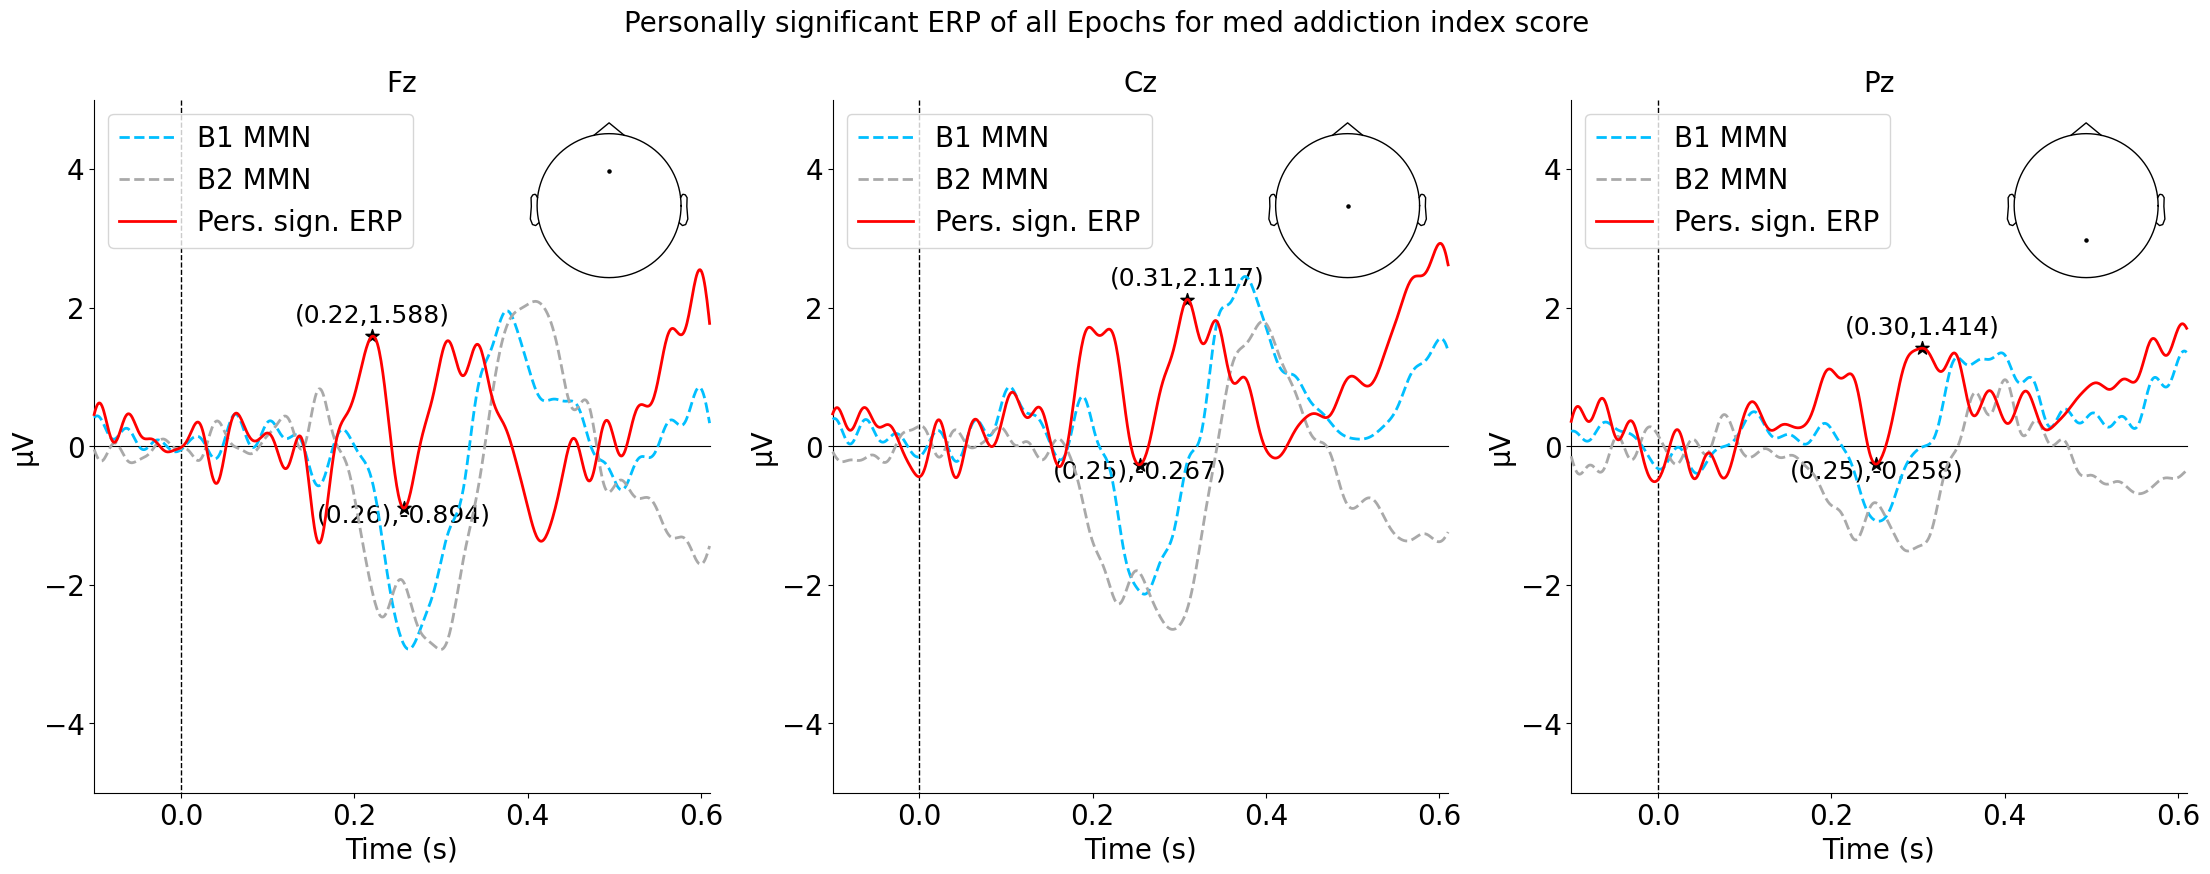

In [20]:
# PS ERp 

evokeds = {'B1 MMN': med_sub_D_B1_MMN_erp,
           'B2 MMN': med_sub_D_B2_MMN_erp,
           "Pers. sign. ERP" : med_sub_D_Personalized_MMN_erp,
           }
# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.61    # End of time window in seconds

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)

# Plot the evoked responses
fig,axs = plt.subplots(1,3,figsize=(27, 9))  # Create a figure and axis


stylesdict ={'B1 MMN': {"linewidth": 2,"linestyle":'--'},
             'B2 MMN': {"linewidth": 2,"linestyle":'--'},
             'Pers. sign. ERP': {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-5,5]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show = False)
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-5, 5]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False)
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2],ylim = dict(eeg=[-5, 5]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False)
print(type(axs[0]))
plot_pos_peak(laten_data["Pers. sign. ERP"]['Fz +(Latency (s),Amplitude (µV))'],axs[0])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Fz- (Latency (s),Amplitude (µV))'],axs[0])
plot_pos_peak(laten_data["Pers. sign. ERP"]['Cz +(Latency (s),Amplitude (µV))'],axs[1])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Cz- (Latency (s),Amplitude (µV))'],axs[1])
plot_pos_peak(laten_data["Pers. sign. ERP"]['Pz +(Latency (s),Amplitude (µV))'],axs[2])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Pz- (Latency (s),Amplitude (µV))'],axs[2])
# Add an overall title for the whole plot
fig.suptitle('Personally significant ERP of all Epochs for med addiction index score', fontsize=20)
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size 
    'legend.fontsize': 20,   # Legend font size
})
plt.show()

{'B1 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.335, 0.165)', 'Fz- (Latency (s),Amplitude (µV))': '(0.247, -4.564)', 'Cz +(Latency (s),Amplitude (µV))': '(0.333, 1.893)', 'Cz- (Latency (s),Amplitude (µV))': '(0.242, -3.66)', 'Pz +(Latency (s),Amplitude (µV))': '(0.4, 0.912)', 'Pz- (Latency (s),Amplitude (µV))': '(0.238, -1.471)'}, 'B2 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.381, 1.544)', 'Fz- (Latency (s),Amplitude (µV))': '(0.302, -4.381)', 'Cz +(Latency (s),Amplitude (µV))': '(0.377, 1.734)', 'Cz- (Latency (s),Amplitude (µV))': '(0.311, -3.435)', 'Pz +(Latency (s),Amplitude (µV))': '(0.378, 1.15)', 'Pz- (Latency (s),Amplitude (µV))': '(0.316, -1.541)'}, 'Pers. sign. ERP': {'Fz +(Latency (s),Amplitude (µV))': '(0.318, 3.394)', 'Fz- (Latency (s),Amplitude (µV))': '(0.384, -3.213)', 'Cz +(Latency (s),Amplitude (µV))': '(0.321, 4.483)', 'Cz- (Latency (s),Amplitude (µV))': '(0.243, -2.82)', 'Pz +(Latency (s),Amplitude (µV))': '(0.322, 1.829)', 'Pz- (Latency (s),Amplitude (µV))'

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\2807889091.py:30: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\2807889091.py:33: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\2807889091.py:36: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


{'B1 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.376, 1.955)', 'Fz- (Latency (s),Amplitude (µV))': '(0.263, -2.929)', 'Cz +(Latency (s),Amplitude (µV))': '(0.376, 2.449)', 'Cz- (Latency (s),Amplitude (µV))': '(0.26, -2.135)', 'Pz +(Latency (s),Amplitude (µV))': '(0.396, 1.348)', 'Pz- (Latency (s),Amplitude (µV))': '(0.255, -1.082)'}, 'B2 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.4, 2.045)', 'Fz- (Latency (s),Amplitude (µV))': '(0.3, -2.934)', 'Cz +(Latency (s),Amplitude (µV))': '(0.396, 1.799)', 'Cz- (Latency (s),Amplitude (µV))': '(0.292, -2.643)', 'Pz +(Latency (s),Amplitude (µV))': '(0.4, 0.96)', 'Pz- (Latency (s),Amplitude (µV))': '(0.288, -1.512)'}, 'Pers. sign. ERP': {'Fz +(Latency (s),Amplitude (µV))': '(0.221, 1.588)', 'Fz- (Latency (s),Amplitude (µV))': '(0.257, -0.894)', 'Cz +(Latency (s),Amplitude (µV))': '(0.309, 2.117)', 'Cz- (Latency (s),Amplitude (µV))': '(0.254, -0.267)', 'Pz +(Latency (s),Amplitude (µV))': '(0.305, 1.414)', 'Pz- (Latency (s),Amplitude (µV))': '

...

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\2807889091.py:110: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\2807889091.py:113: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\2807889091.py:116: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\2807889091.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


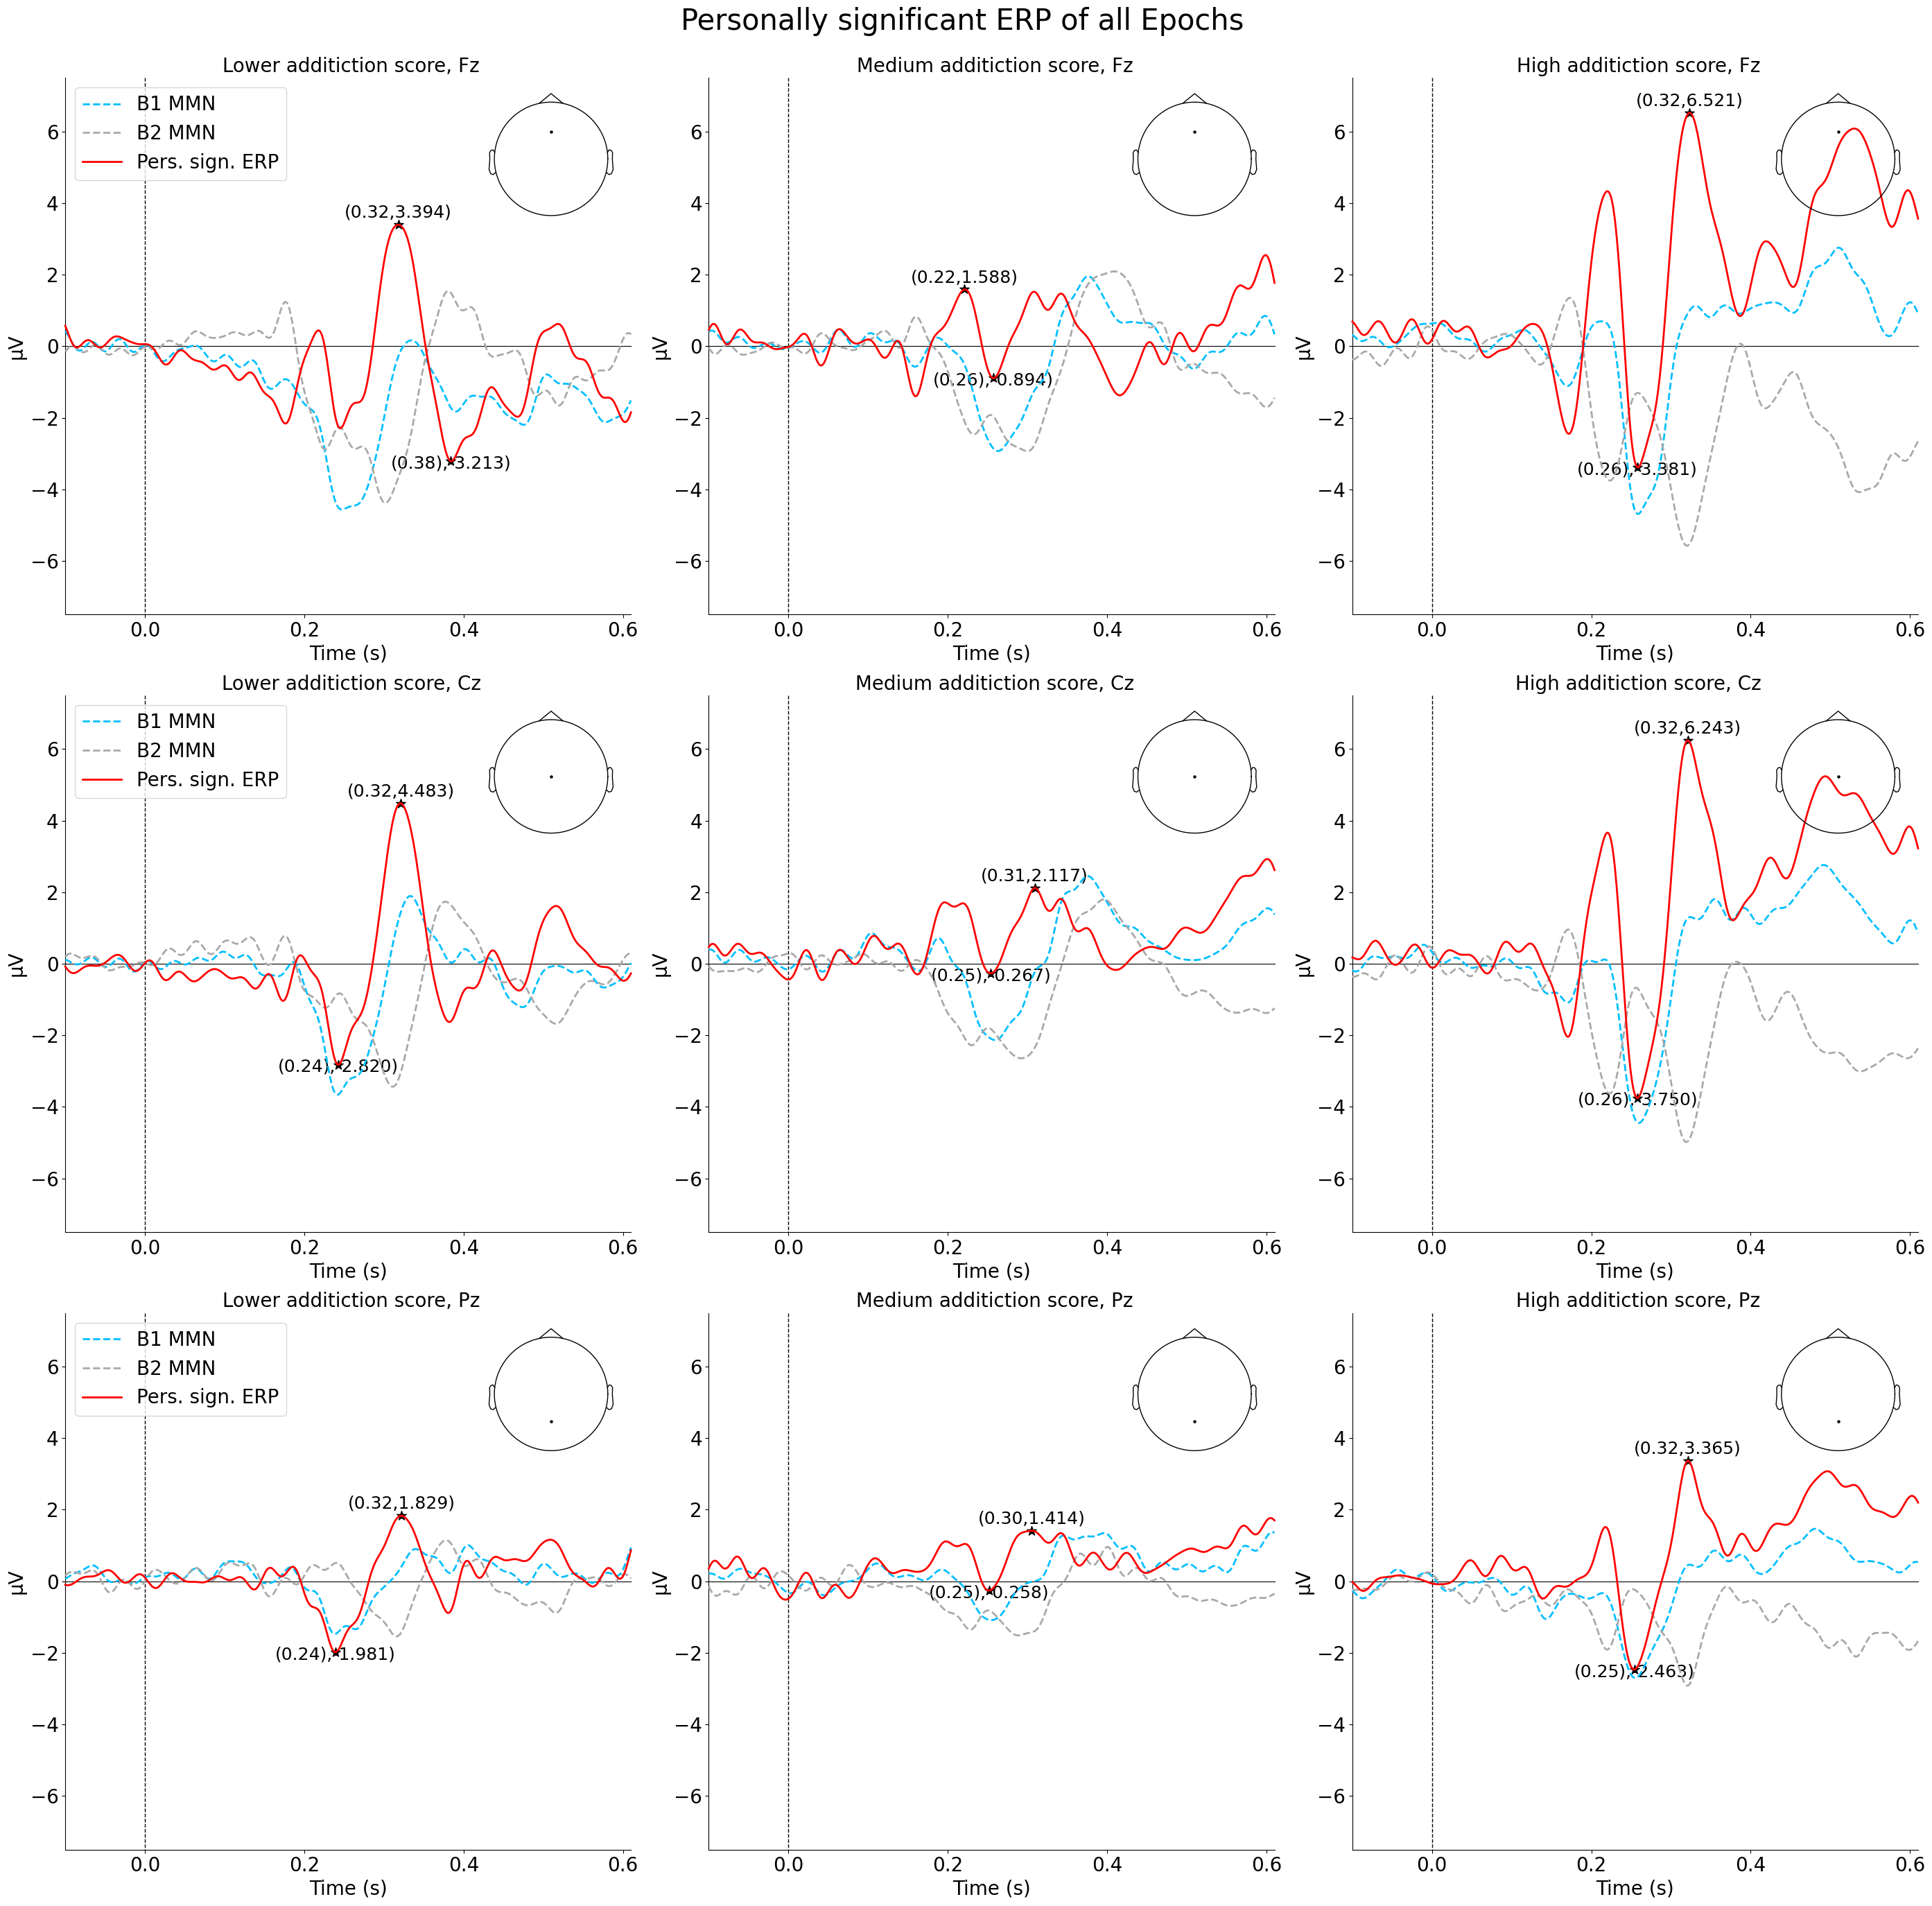

In [21]:
# PS ERp 
# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.61    # End of time window in seconds


# ### Low addiction score 
evokeds = {'B1 MMN': low_sub_D_B1_MMN_erp,
           'B2 MMN': low_sub_D_B2_MMN_erp,
           "Pers. sign. ERP" : low_sub_D_Personalized_MMN_erp,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)

# Plot the evoked responses
fig,axs = plt.subplots(3,3,figsize=(28, 28))  # Create a figure and axis
stylesdict ={'B1 MMN': {"linewidth": 2,"linestyle":'--'},
             'B2 MMN': {"linewidth": 2,"linestyle":'--'},
             'Pers. sign. ERP': {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0,0],ylim = dict(eeg=[-7.5,7.5]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show = False,title=" Lower additiction score, " + str(picks[0]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1,0],ylim = dict(eeg=[-7.5,7.5]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title=" Lower additiction score, " + str(picks[1]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2,0],ylim = dict(eeg=[-7.5,7.5]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title=" Lower additiction score, " + str(picks[2]))

plot_pos_peak(laten_data["Pers. sign. ERP"]['Fz +(Latency (s),Amplitude (µV))'],axs[0,0])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Fz- (Latency (s),Amplitude (µV))'],axs[0,0])
plot_pos_peak(laten_data["Pers. sign. ERP"]['Cz +(Latency (s),Amplitude (µV))'],axs[1,0])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Cz- (Latency (s),Amplitude (µV))'],axs[1,0])
plot_pos_peak(laten_data["Pers. sign. ERP"]['Pz +(Latency (s),Amplitude (µV))'],axs[2,0])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Pz- (Latency (s),Amplitude (µV))'],axs[2,0])


### Med addiction score index 


evokeds = {'B1 MMN': med_sub_D_B1_MMN_erp,
           'B2 MMN': med_sub_D_B2_MMN_erp,
           "Pers. sign. ERP" : med_sub_D_Personalized_MMN_erp,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)

stylesdict ={'B1 MMN': {"linewidth": 2,"linestyle":'--'},
             'B2 MMN': {"linewidth": 2,"linestyle":'--'},
             'Pers. sign. ERP': {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0,1],ylim = dict(eeg=[-7.5,7.5]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show = False,legend=False,title=" Medium additiction score, " + str(picks[0]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1,1],ylim = dict(eeg=[-7.5,7.5]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title=" Medium additiction score, " + str(picks[1]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2,1],ylim = dict(eeg=[-7.5,7.5]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title=" Medium additiction score, " + str(picks[2]))

plot_pos_peak(laten_data["Pers. sign. ERP"]['Fz +(Latency (s),Amplitude (µV))'],axs[0,1])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Fz- (Latency (s),Amplitude (µV))'],axs[0,1])
plot_pos_peak(laten_data["Pers. sign. ERP"]['Cz +(Latency (s),Amplitude (µV))'],axs[1,1])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Cz- (Latency (s),Amplitude (µV))'],axs[1,1])
plot_pos_peak(laten_data["Pers. sign. ERP"]['Pz +(Latency (s),Amplitude (µV))'],axs[2,1])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Pz- (Latency (s),Amplitude (µV))'],axs[2,1])


### High addiction score ###
evokeds = {'B1 MMN': high_sub_D_B1_MMN_erp,
           'B2 MMN': high_sub_D_B2_MMN_erp,
           "Pers. sign. ERP" : high_sub_D_Personalized_MMN_erp,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)

stylesdict ={'B1 MMN': {"linewidth": 2,"linestyle":'--'},
             'B2 MMN': {"linewidth": 2,"linestyle":'--'},
             'Pers. sign. ERP': {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0,2],ylim = dict(eeg=[-7.5,7.5]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show = False,legend=False,title=" High additiction score, " + str(picks[0]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1,2],ylim = dict(eeg=[-7.5,7.5]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title=" High additiction score, " + str(picks[1]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2,2],ylim = dict(eeg=[-7.5,7.5]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title=" High additiction score, " + str(picks[2]))

plot_pos_peak(laten_data["Pers. sign. ERP"]['Fz +(Latency (s),Amplitude (µV))'],axs[0,2])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Fz- (Latency (s),Amplitude (µV))'],axs[0,2])
plot_pos_peak(laten_data["Pers. sign. ERP"]['Cz +(Latency (s),Amplitude (µV))'],axs[1,2])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Cz- (Latency (s),Amplitude (µV))'],axs[1,2])
plot_pos_peak(laten_data["Pers. sign. ERP"]['Pz +(Latency (s),Amplitude (µV))'],axs[2,2])
plot_neg_peak(laten_data["Pers. sign. ERP"]['Pz- (Latency (s),Amplitude (µV))'],axs[2,2])


# Add an overall title for the whole plot
fig.suptitle('Personally significant ERP of all Epochs ', fontsize=30)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size 
    'legend.fontsize': 20,   # Legend font size
})
plt.show()

### Block 1 MMN  plot 

{'Pers. deviant': {'Fz +(Latency (s),Amplitude (µV))': "('Na', 'Na')", 'Fz- (Latency (s),Amplitude (µV))': '(0.235, -6.639)', 'Cz +(Latency (s),Amplitude (µV))': '(0.327, 1.574)', 'Cz- (Latency (s),Amplitude (µV))': '(0.236, -5.176)', 'Pz +(Latency (s),Amplitude (µV))': '(0.332, 0.441)', 'Pz- (Latency (s),Amplitude (µV))': '(0.236, -2.273)'}, 'non. sign. standard': {'Fz +(Latency (s),Amplitude (µV))': '(0.283, 1.3)', 'Fz- (Latency (s),Amplitude (µV))': '(0.22, -3.515)', 'Cz +(Latency (s),Amplitude (µV))': '(0.284, 1.246)', 'Cz- (Latency (s),Amplitude (µV))': '(0.217, -2.686)', 'Pz +(Latency (s),Amplitude (µV))': '(0.278, 0.181)', 'Pz- (Latency (s),Amplitude (µV))': '(0.4, -1.323)'}, 'B1 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.335, 0.165)', 'Fz- (Latency (s),Amplitude (µV))': '(0.247, -4.564)', 'Cz +(Latency (s),Amplitude (µV))': '(0.333, 1.893)', 'Cz- (Latency (s),Amplitude (µV))': '(0.242, -3.66)', 'Pz +(Latency (s),Amplitude (µV))': '(0.4, 0.912)', 'Pz- (Latency (s),Amplitude 

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\906986587.py:31: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\906986587.py:34: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
{'Pers. deviant': {'Fz +(Latency (s),Amplitude (µV))': "('Na', 'Na')", 'Fz- (Latency (s),Amplitude (µV))': '(0.24, -3.268)', 'Cz +(Latency (s),Amplitude (µV))': '(0.349, 1.008)', 'Cz- (Latency (s),Amplitude (µV))': '(0.236, -2.908)', 'Pz +(Latency (s),Amplitude (µV))': '(0.346, 0.704)', 'Pz- (Latency (s),Amplitude (µV))': '(0.238, -1.557)'}, 'non. sign. standard': {'Fz +(Latency (s),Amplitude (µV))': '(0.284, 1.245)', 'Fz- (Latency (s),Amplitude (µV))': '(0.4, -2.928)', 'Cz +(Latency (s),Amplitude (µV))': '(0.284, 1.246)', 'Cz- (Latency (s),Amplitude (µV))': '(0.4, -2.367)', 'Pz +(Latency (s),Amplitude (µV))': '(0.293, 0.53)', 'Pz- (Latency (s),Amplitude (µV))': '(0.4, -1.027)'}, 'B1 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.376, 1.955)', 'Fz- (Latency (s),Amplitude (µV))': '(0.263, -2.929)',

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\906986587.py:37: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


...

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\906986587.py:106: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\906986587.py:109: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\906986587.py:112: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\906986587.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


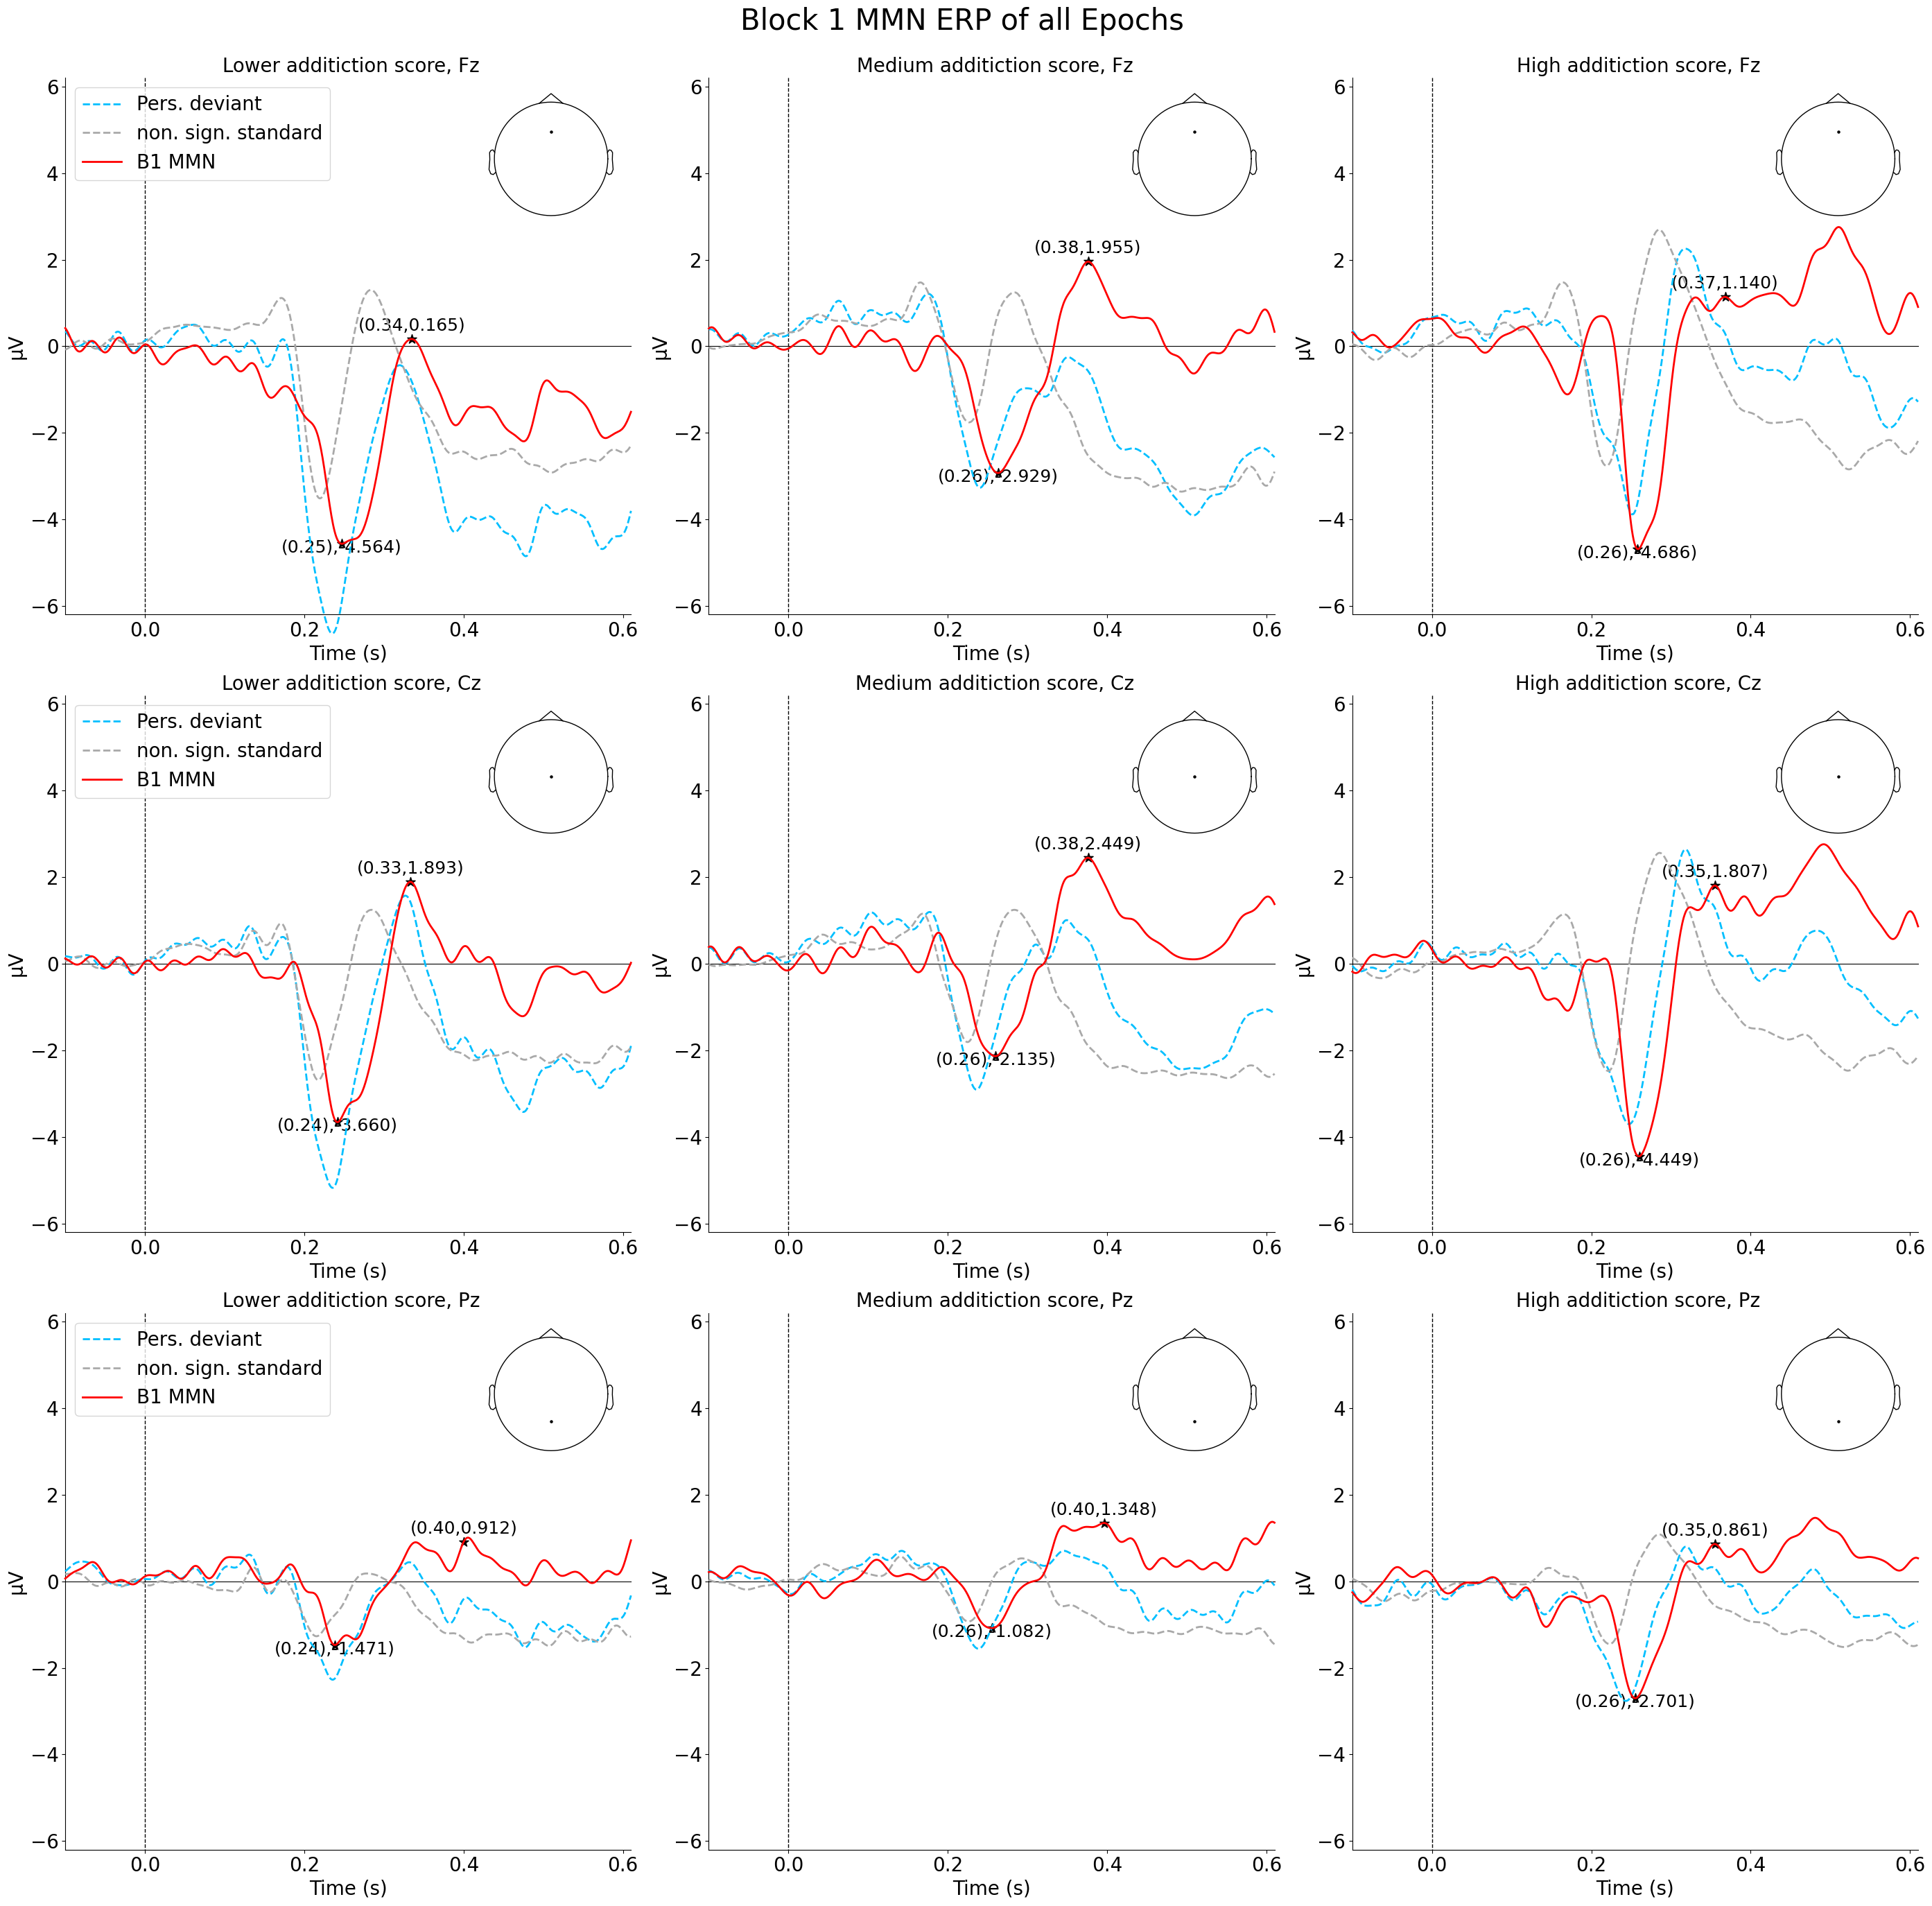

In [22]:
# PS ERp 
# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.61    # End of time window in seconds


# ### Low addiction score 
evokeds = {'Pers. deviant': low_sub_D_B1_devi_eps,
           'non. sign. standard': low_sub_D_B1_sta_eps,
           "B1 MMN" : low_sub_D_B1_MMN_erp,
           }
stylesdict ={'Pers. deviant': {"linewidth": 2,"linestyle":'--'},
             'non. sign. standard': {"linewidth": 2,"linestyle":'--'},
             "B1 MMN": {"linewidth": 2,"linestyle":'solid'},
             }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)

# Plot the evoked responses
fig,axs = plt.subplots(3,3,figsize=(28, 28))  # Create a figure and axis

mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0,0],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show = False,title=" Lower additiction score, " + str(picks[0]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1,0],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title=" Lower additiction score, " + str(picks[1]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2,0],ylim =dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title=" Lower additiction score, " + str(picks[2]))

plot_pos_peak(laten_data["B1 MMN"]['Fz +(Latency (s),Amplitude (µV))'],axs[0,0])
plot_neg_peak(laten_data["B1 MMN"]['Fz- (Latency (s),Amplitude (µV))'],axs[0,0])
plot_pos_peak(laten_data["B1 MMN"]['Cz +(Latency (s),Amplitude (µV))'],axs[1,0])
plot_neg_peak(laten_data["B1 MMN"]['Cz- (Latency (s),Amplitude (µV))'],axs[1,0])
plot_pos_peak(laten_data["B1 MMN"]['Pz +(Latency (s),Amplitude (µV))'],axs[2,0])
plot_neg_peak(laten_data["B1 MMN"]['Pz- (Latency (s),Amplitude (µV))'],axs[2,0])


### Med addiction score index 

evokeds = {'Pers. deviant': med_sub_D_B1_devi_eps,
           'non. sign. standard': med_sub_D_B1_sta_eps,
           "B1 MMN" : med_sub_D_B1_MMN_erp,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)


mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0,1],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show = False,legend=False,title=" Medium additiction score, " + str(picks[0]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1,1],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title=" Medium additiction score, " + str(picks[1]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2,1],ylim =dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title=" Medium additiction score, " + str(picks[2]))

plot_pos_peak(laten_data["B1 MMN"]['Fz +(Latency (s),Amplitude (µV))'],axs[0,1])
plot_neg_peak(laten_data["B1 MMN"]['Fz- (Latency (s),Amplitude (µV))'],axs[0,1])
plot_pos_peak(laten_data["B1 MMN"]['Cz +(Latency (s),Amplitude (µV))'],axs[1,1])
plot_neg_peak(laten_data["B1 MMN"]['Cz- (Latency (s),Amplitude (µV))'],axs[1,1])
plot_pos_peak(laten_data["B1 MMN"]['Pz +(Latency (s),Amplitude (µV))'],axs[2,1])
plot_neg_peak(laten_data["B1 MMN"]['Pz- (Latency (s),Amplitude (µV))'],axs[2,1])


### High addiction score ###
evokeds = {'Pers. deviant': high_sub_D_B1_devi_eps,
           'non. sign. standard': high_sub_D_B1_sta_eps,
           "B1 MMN" : high_sub_D_B1_MMN_erp,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)


mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0,2],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show = False,legend=False,title=" High additiction score, " + str(picks[0]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1,2],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title=" High additiction score, " + str(picks[1]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2,2],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title=" High additiction score, " + str(picks[2]))

plot_pos_peak(laten_data["B1 MMN"]['Fz +(Latency (s),Amplitude (µV))'],axs[0,2])
plot_neg_peak(laten_data["B1 MMN"]['Fz- (Latency (s),Amplitude (µV))'],axs[0,2])
plot_pos_peak(laten_data["B1 MMN"]['Cz +(Latency (s),Amplitude (µV))'],axs[1,2])
plot_neg_peak(laten_data["B1 MMN"]['Cz- (Latency (s),Amplitude (µV))'],axs[1,2])
plot_pos_peak(laten_data["B1 MMN"]['Pz +(Latency (s),Amplitude (µV))'],axs[2,2])
plot_neg_peak(laten_data["B1 MMN"]['Pz- (Latency (s),Amplitude (µV))'],axs[2,2])


# Add an overall title for the whole plot
fig.suptitle('Block 1 MMN ERP of all Epochs ', fontsize=30)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size 
    'legend.fontsize': 20,   # Legend font size
})
plt.show()

### B2 MMN score  

{'non. sign. deviant': {'Fz +(Latency (s),Amplitude (µV))': "('Na', 'Na')", 'Fz- (Latency (s),Amplitude (µV))': '(0.226, -5.685)', 'Cz +(Latency (s),Amplitude (µV))': '(0.364, 0.322)', 'Cz- (Latency (s),Amplitude (µV))': '(0.224, -3.754)', 'Pz +(Latency (s),Amplitude (µV))': '(0.358, 0.292)', 'Pz- (Latency (s),Amplitude (µV))': '(0.314, -1.203)'}, 'Pers. standard': {'Fz +(Latency (s),Amplitude (µV))': '(0.307, 1.183)', 'Fz- (Latency (s),Amplitude (µV))': '(0.4, -3.231)', 'Cz +(Latency (s),Amplitude (µV))': '(0.314, 1.573)', 'Cz- (Latency (s),Amplitude (µV))': '(0.222, -2.545)', 'Pz +(Latency (s),Amplitude (µV))': '(0.324, 0.387)', 'Pz- (Latency (s),Amplitude (µV))': '(0.222, -1.423)'}, 'B2 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.381, 1.544)', 'Fz- (Latency (s),Amplitude (µV))': '(0.302, -4.381)', 'Cz +(Latency (s),Amplitude (µV))': '(0.377, 1.734)', 'Cz- (Latency (s),Amplitude (µV))': '(0.311, -3.435)', 'Pz +(Latency (s),Amplitude (µV))': '(0.378, 1.15)', 'Pz- (Latency (s),Ampli

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\2961859727.py:31: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\2961859727.py:34: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\2961859727.py:37: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


{'non. sign. deviant': {'Fz +(Latency (s),Amplitude (µV))': '(0.368, 0.281)', 'Fz- (Latency (s),Amplitude (µV))': '(0.234, -2.764)', 'Cz +(Latency (s),Amplitude (µV))': '(0.359, 0.693)', 'Cz- (Latency (s),Amplitude (µV))': '(0.229, -2.841)', 'Pz +(Latency (s),Amplitude (µV))': '(0.363, 0.412)', 'Pz- (Latency (s),Amplitude (µV))': '(0.228, -1.76)'}, 'Pers. standard': {'Fz +(Latency (s),Amplitude (µV))': '(0.285, 1.628)', 'Fz- (Latency (s),Amplitude (µV))': '(0.4, -2.549)', 'Cz +(Latency (s),Amplitude (µV))': '(0.289, 1.633)', 'Cz- (Latency (s),Amplitude (µV))': '(0.4, -1.985)', 'Pz +(Latency (s),Amplitude (µV))': '(0.297, 0.765)', 'Pz- (Latency (s),Amplitude (µV))': '(0.4, -0.936)'}, 'B2 MMN': {'Fz +(Latency (s),Amplitude (µV))': '(0.4, 2.045)', 'Fz- (Latency (s),Amplitude (µV))': '(0.3, -2.934)', 'Cz +(Latency (s),Amplitude (µV))': '(0.396, 1.799)', 'Cz- (Latency (s),Amplitude (µV))': '(0.292, -2.643)', 'Pz +(Latency (s),Amplitude (µV))': '(0.4, 0.96)', 'Pz- (Latency (s),Amplitude (µV)

...

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\2961859727.py:110: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\2961859727.py:113: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


Axes(0.672059,0.11;0.227941x0.226471) is string 


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\2961859727.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


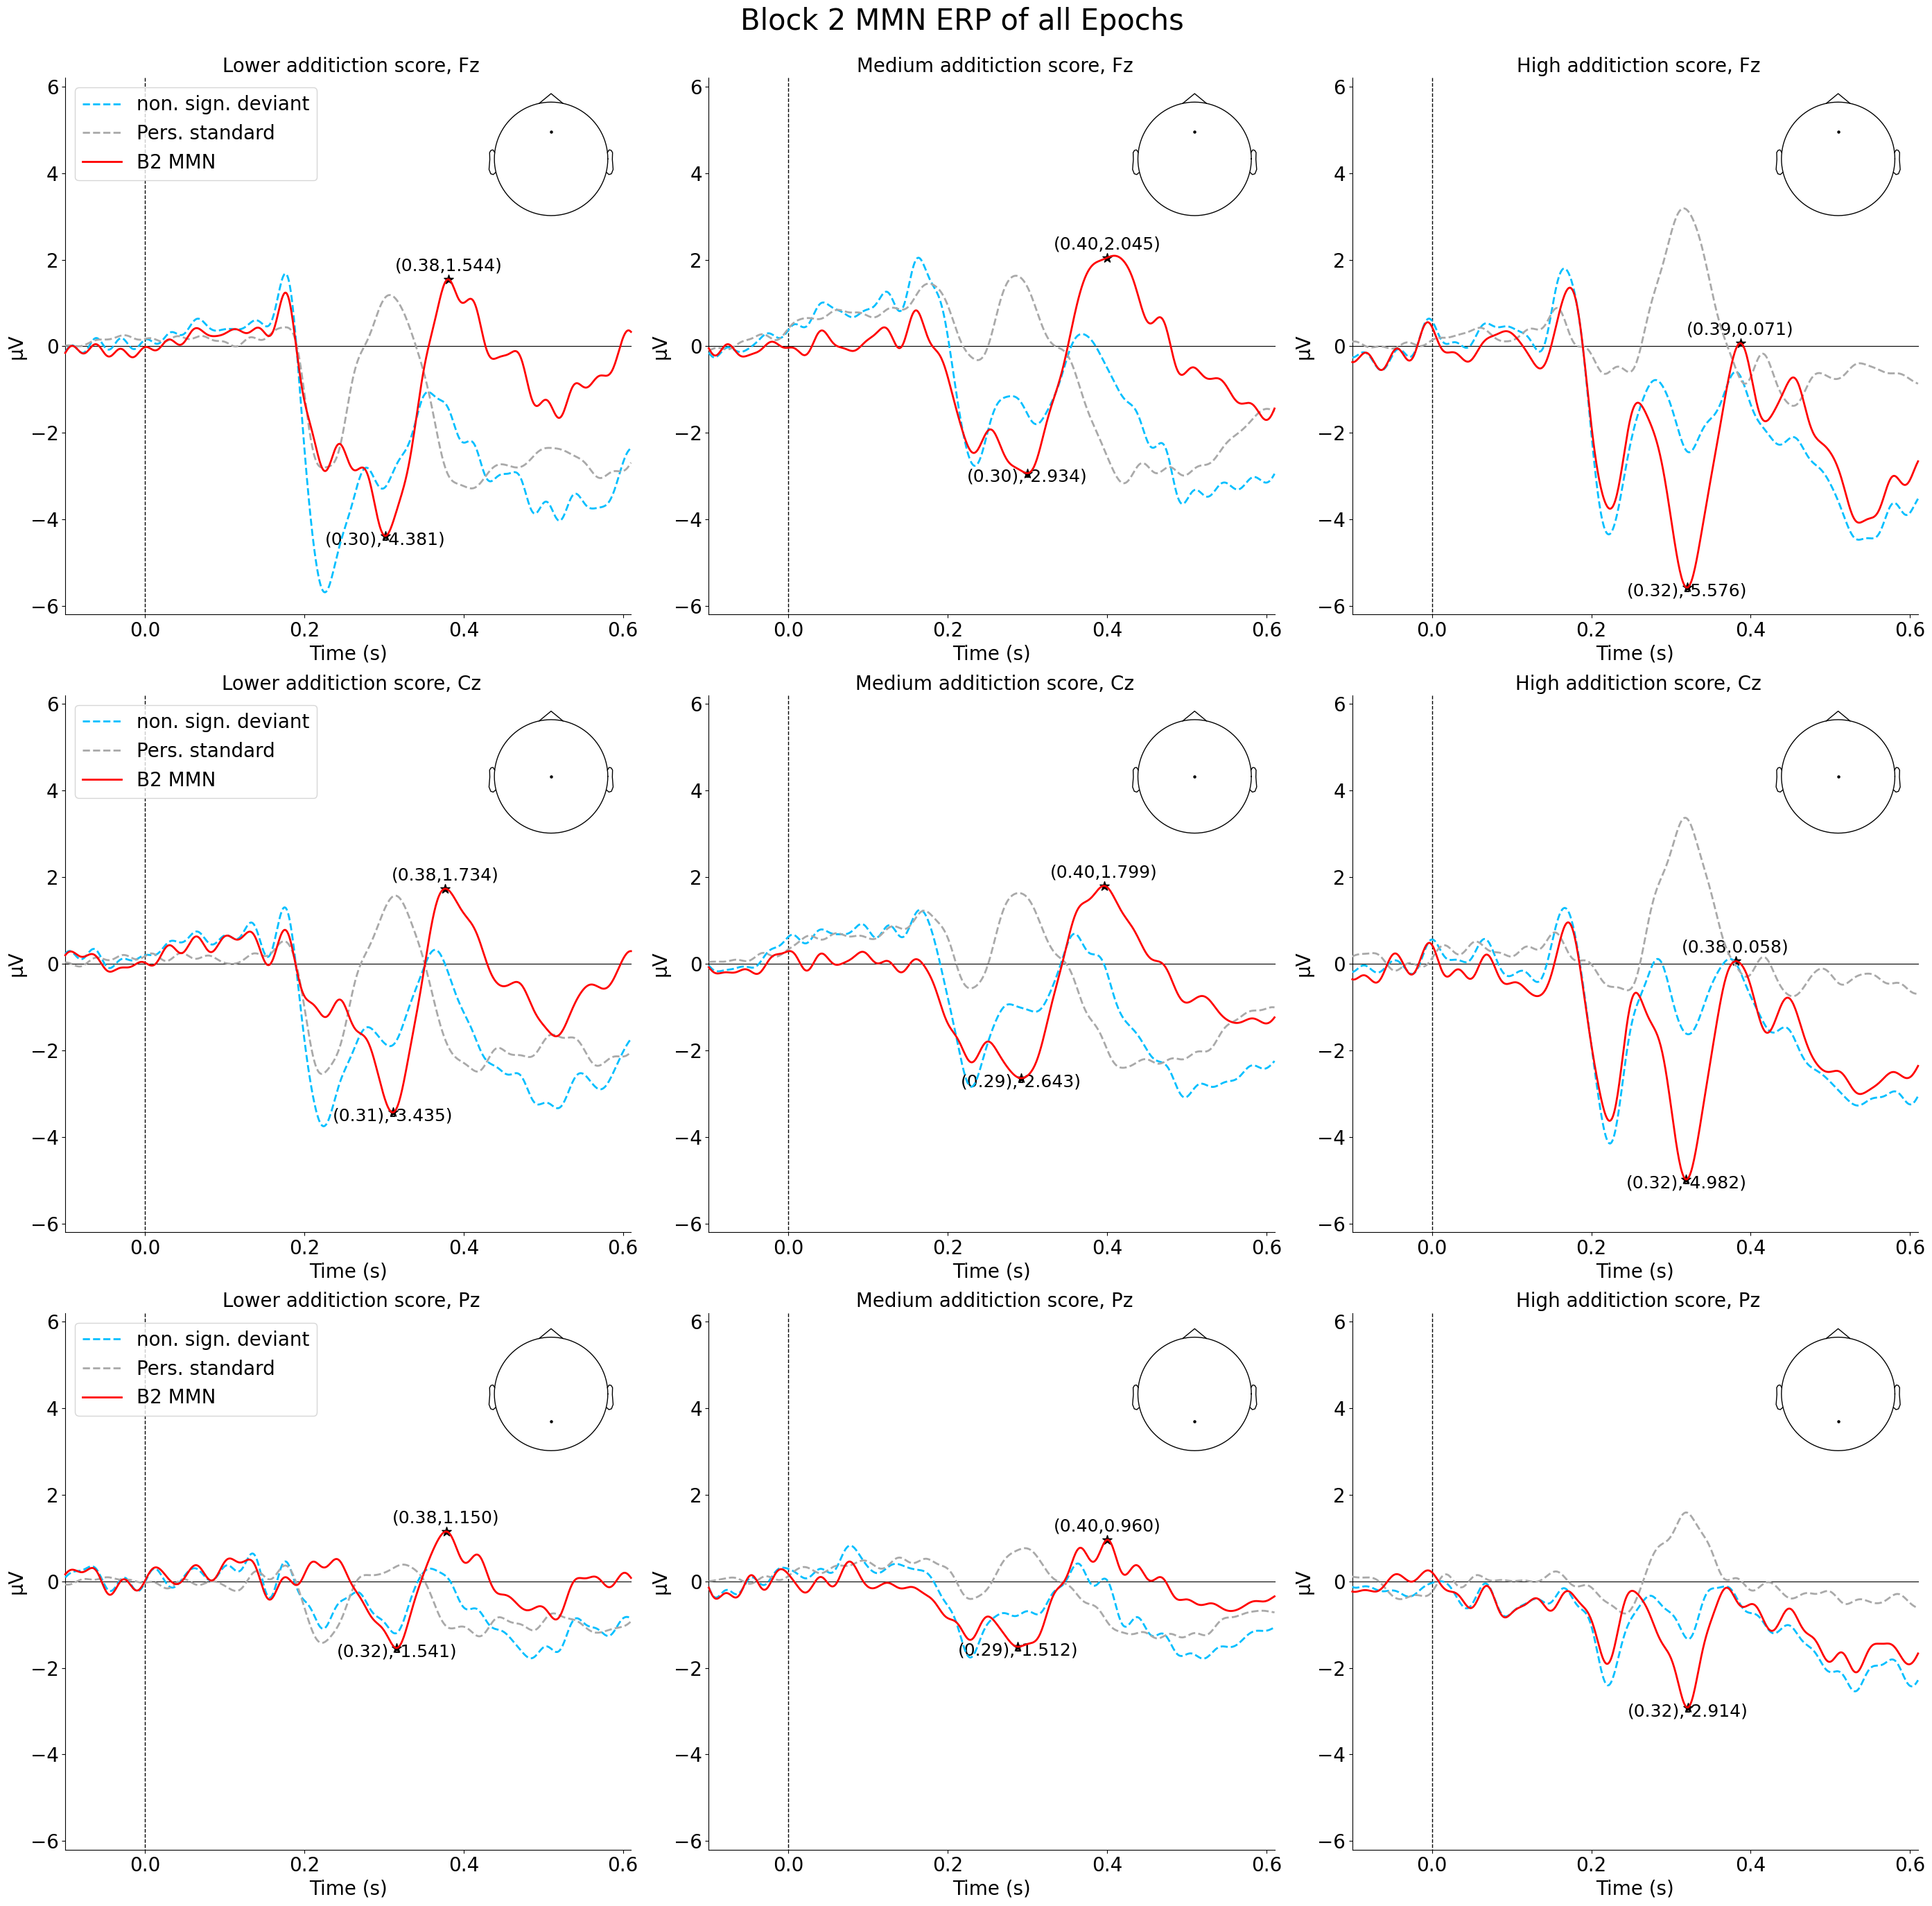

In [23]:
# PS ERp 
# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.61    # End of time window in seconds


# ### Low addiction score 
evokeds = {'non. sign. deviant': low_sub_D_B2_devi_eps,
           'Pers. standard': low_sub_D_B2_sta_eps,
           "B2 MMN"  : low_sub_D_B2_MMN_erp,
           }
stylesdict ={'non. sign. deviant': {"linewidth": 2,"linestyle":'--'},
             'Pers. standard': {"linewidth": 2,"linestyle":'--'},
             "B2 MMN" : {"linewidth": 2,"linestyle":'solid'},
             }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)

# Plot the evoked responses
fig,axs = plt.subplots(3,3,figsize=(28, 28))  # Create a figure and axis

mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0,0],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show = False,title=" Lower additiction score, " + str(picks[0]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1,0],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title=" Lower additiction score, " + str(picks[1]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2,0],ylim =dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title=" Lower additiction score, " + str(picks[2]))

plot_pos_peak(laten_data["B2 MMN"]['Fz +(Latency (s),Amplitude (µV))'],axs[0,0])
plot_neg_peak(laten_data["B2 MMN"]['Fz- (Latency (s),Amplitude (µV))'],axs[0,0])
plot_pos_peak(laten_data["B2 MMN"]['Cz +(Latency (s),Amplitude (µV))'],axs[1,0])
plot_neg_peak(laten_data["B2 MMN"]['Cz- (Latency (s),Amplitude (µV))'],axs[1,0])
plot_pos_peak(laten_data["B2 MMN"]['Pz +(Latency (s),Amplitude (µV))'],axs[2,0])
plot_neg_peak(laten_data["B2 MMN"]['Pz- (Latency (s),Amplitude (µV))'],axs[2,0])


### Med addiction score index 

evokeds = {'non. sign. deviant': med_sub_D_B2_devi_eps,
           'Pers. standard': med_sub_D_B2_sta_eps,
           "B2 MMN" : med_sub_D_B2_MMN_erp,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)


mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0,1],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show = False,legend=False,title=" Medium additiction score, " + str(picks[0]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1,1],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title=" Medium additiction score, " + str(picks[1]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2,1],ylim =dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title=" Medium additiction score, " + str(picks[2]))

plot_pos_peak(laten_data["B2 MMN"]['Fz +(Latency (s),Amplitude (µV))'],axs[0,1])
plot_neg_peak(laten_data["B2 MMN"]['Fz- (Latency (s),Amplitude (µV))'],axs[0,1])
plot_pos_peak(laten_data["B2 MMN"]['Cz +(Latency (s),Amplitude (µV))'],axs[1,1])
plot_neg_peak(laten_data["B2 MMN"]['Cz- (Latency (s),Amplitude (µV))'],axs[1,1])
plot_pos_peak(laten_data["B2 MMN"]['Pz +(Latency (s),Amplitude (µV))'],axs[2,1])
plot_neg_peak(laten_data["B2 MMN"]['Pz- (Latency (s),Amplitude (µV))'],axs[2,1])


### High addiction score ###

evokeds = {'non. sign. deviant': high_sub_D_B2_devi_eps,
           'Pers. standard': high_sub_D_B2_sta_eps,
           "B2 MMN" : high_sub_D_B2_MMN_erp,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)


mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0,2],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show = False,legend=False,title=" High additiction score, " + str(picks[0]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1,2],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title=" High additiction score, " + str(picks[1]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2,2],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title=" High additiction score, " + str(picks[2]))

plot_pos_peak(laten_data["B2 MMN"]['Fz +(Latency (s),Amplitude (µV))'],axs[0,2])
plot_neg_peak(laten_data["B2 MMN"]['Fz- (Latency (s),Amplitude (µV))'],axs[0,2])
plot_pos_peak(laten_data["B2 MMN"]['Cz +(Latency (s),Amplitude (µV))'],axs[1,2])
plot_neg_peak(laten_data["B2 MMN"]['Cz- (Latency (s),Amplitude (µV))'],axs[1,2])
plot_pos_peak(laten_data["B2 MMN"]['Pz +(Latency (s),Amplitude (µV))'],axs[2,2])
plot_neg_peak(laten_data["B2 MMN"]['Pz- (Latency (s),Amplitude (µV))'],axs[2,2])


# Add an overall title for the whole plot
fig.suptitle('Block 2 MMN ERP of all Epochs ', fontsize=30)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size 
    'legend.fontsize': 20,   # Legend font size
})
plt.show()

{'low score': {'Fz +(Latency (s),Amplitude (µV))': '(0.335, 0.165)', 'Fz- (Latency (s),Amplitude (µV))': '(0.247, -4.564)', 'Cz +(Latency (s),Amplitude (µV))': '(0.333, 1.893)', 'Cz- (Latency (s),Amplitude (µV))': '(0.242, -3.66)', 'Pz +(Latency (s),Amplitude (µV))': '(0.4, 0.912)', 'Pz- (Latency (s),Amplitude (µV))': '(0.238, -1.471)'}, 'Medium score': {'Fz +(Latency (s),Amplitude (µV))': '(0.376, 1.955)', 'Fz- (Latency (s),Amplitude (µV))': '(0.263, -2.929)', 'Cz +(Latency (s),Amplitude (µV))': '(0.376, 2.449)', 'Cz- (Latency (s),Amplitude (µV))': '(0.26, -2.135)', 'Pz +(Latency (s),Amplitude (µV))': '(0.396, 1.348)', 'Pz- (Latency (s),Amplitude (µV))': '(0.255, -1.082)'}, 'High score': {'Fz +(Latency (s),Amplitude (µV))': '(0.368, 1.14)', 'Fz- (Latency (s),Amplitude (µV))': '(0.258, -4.686)', 'Cz +(Latency (s),Amplitude (µV))': '(0.355, 1.807)', 'Cz- (Latency (s),Amplitude (µV))': '(0.26, -4.449)', 'Pz +(Latency (s),Amplitude (µV))': '(0.355, 0.861)', 'Pz- (Latency (s),Amplitude (µV

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\3024745420.py:31: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\3024745420.py:34: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\3024745420.py:37: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],


{'low score': {'Fz +(Latency (s),Amplitude (µV))': '(0.381, 1.544)', 'Fz- (Latency (s),Amplitude (µV))': '(0.302, -4.381)', 'Cz +(Latency (s),Amplitude (µV))': '(0.377, 1.734)', 'Cz- (Latency (s),Amplitude (µV))': '(0.311, -3.435)', 'Pz +(Latency (s),Amplitude (µV))': '(0.378, 1.15)', 'Pz- (Latency (s),Amplitude (µV))': '(0.316, -1.541)'}, 'Medium score': {'Fz +(Latency (s),Amplitude (µV))': '(0.4, 2.045)', 'Fz- (Latency (s),Amplitude (µV))': '(0.3, -2.934)', 'Cz +(Latency (s),Amplitude (µV))': '(0.396, 1.799)', 'Cz- (Latency (s),Amplitude (µV))': '(0.292, -2.643)', 'Pz +(Latency (s),Amplitude (µV))': '(0.4, 0.96)', 'Pz- (Latency (s),Amplitude (µV))': '(0.288, -1.512)'}, 'High score': {'Fz +(Latency (s),Amplitude (µV))': '(0.387, 0.071)', 'Fz- (Latency (s),Amplitude (µV))': '(0.32, -5.576)', 'Cz +(Latency (s),Amplitude (µV))': '(0.381, 0.058)', 'Cz- (Latency (s),Amplitude (µV))': '(0.319, -4.982)', 'Pz +(Latency (s),Amplitude (µV))': "('Na', 'Na')", 'Pz- (Latency (s),Amplitude (µV))': 

...

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\3024745420.py:107: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\3024745420.py:110: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\3024745420.py:113: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_23468\3024745420.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


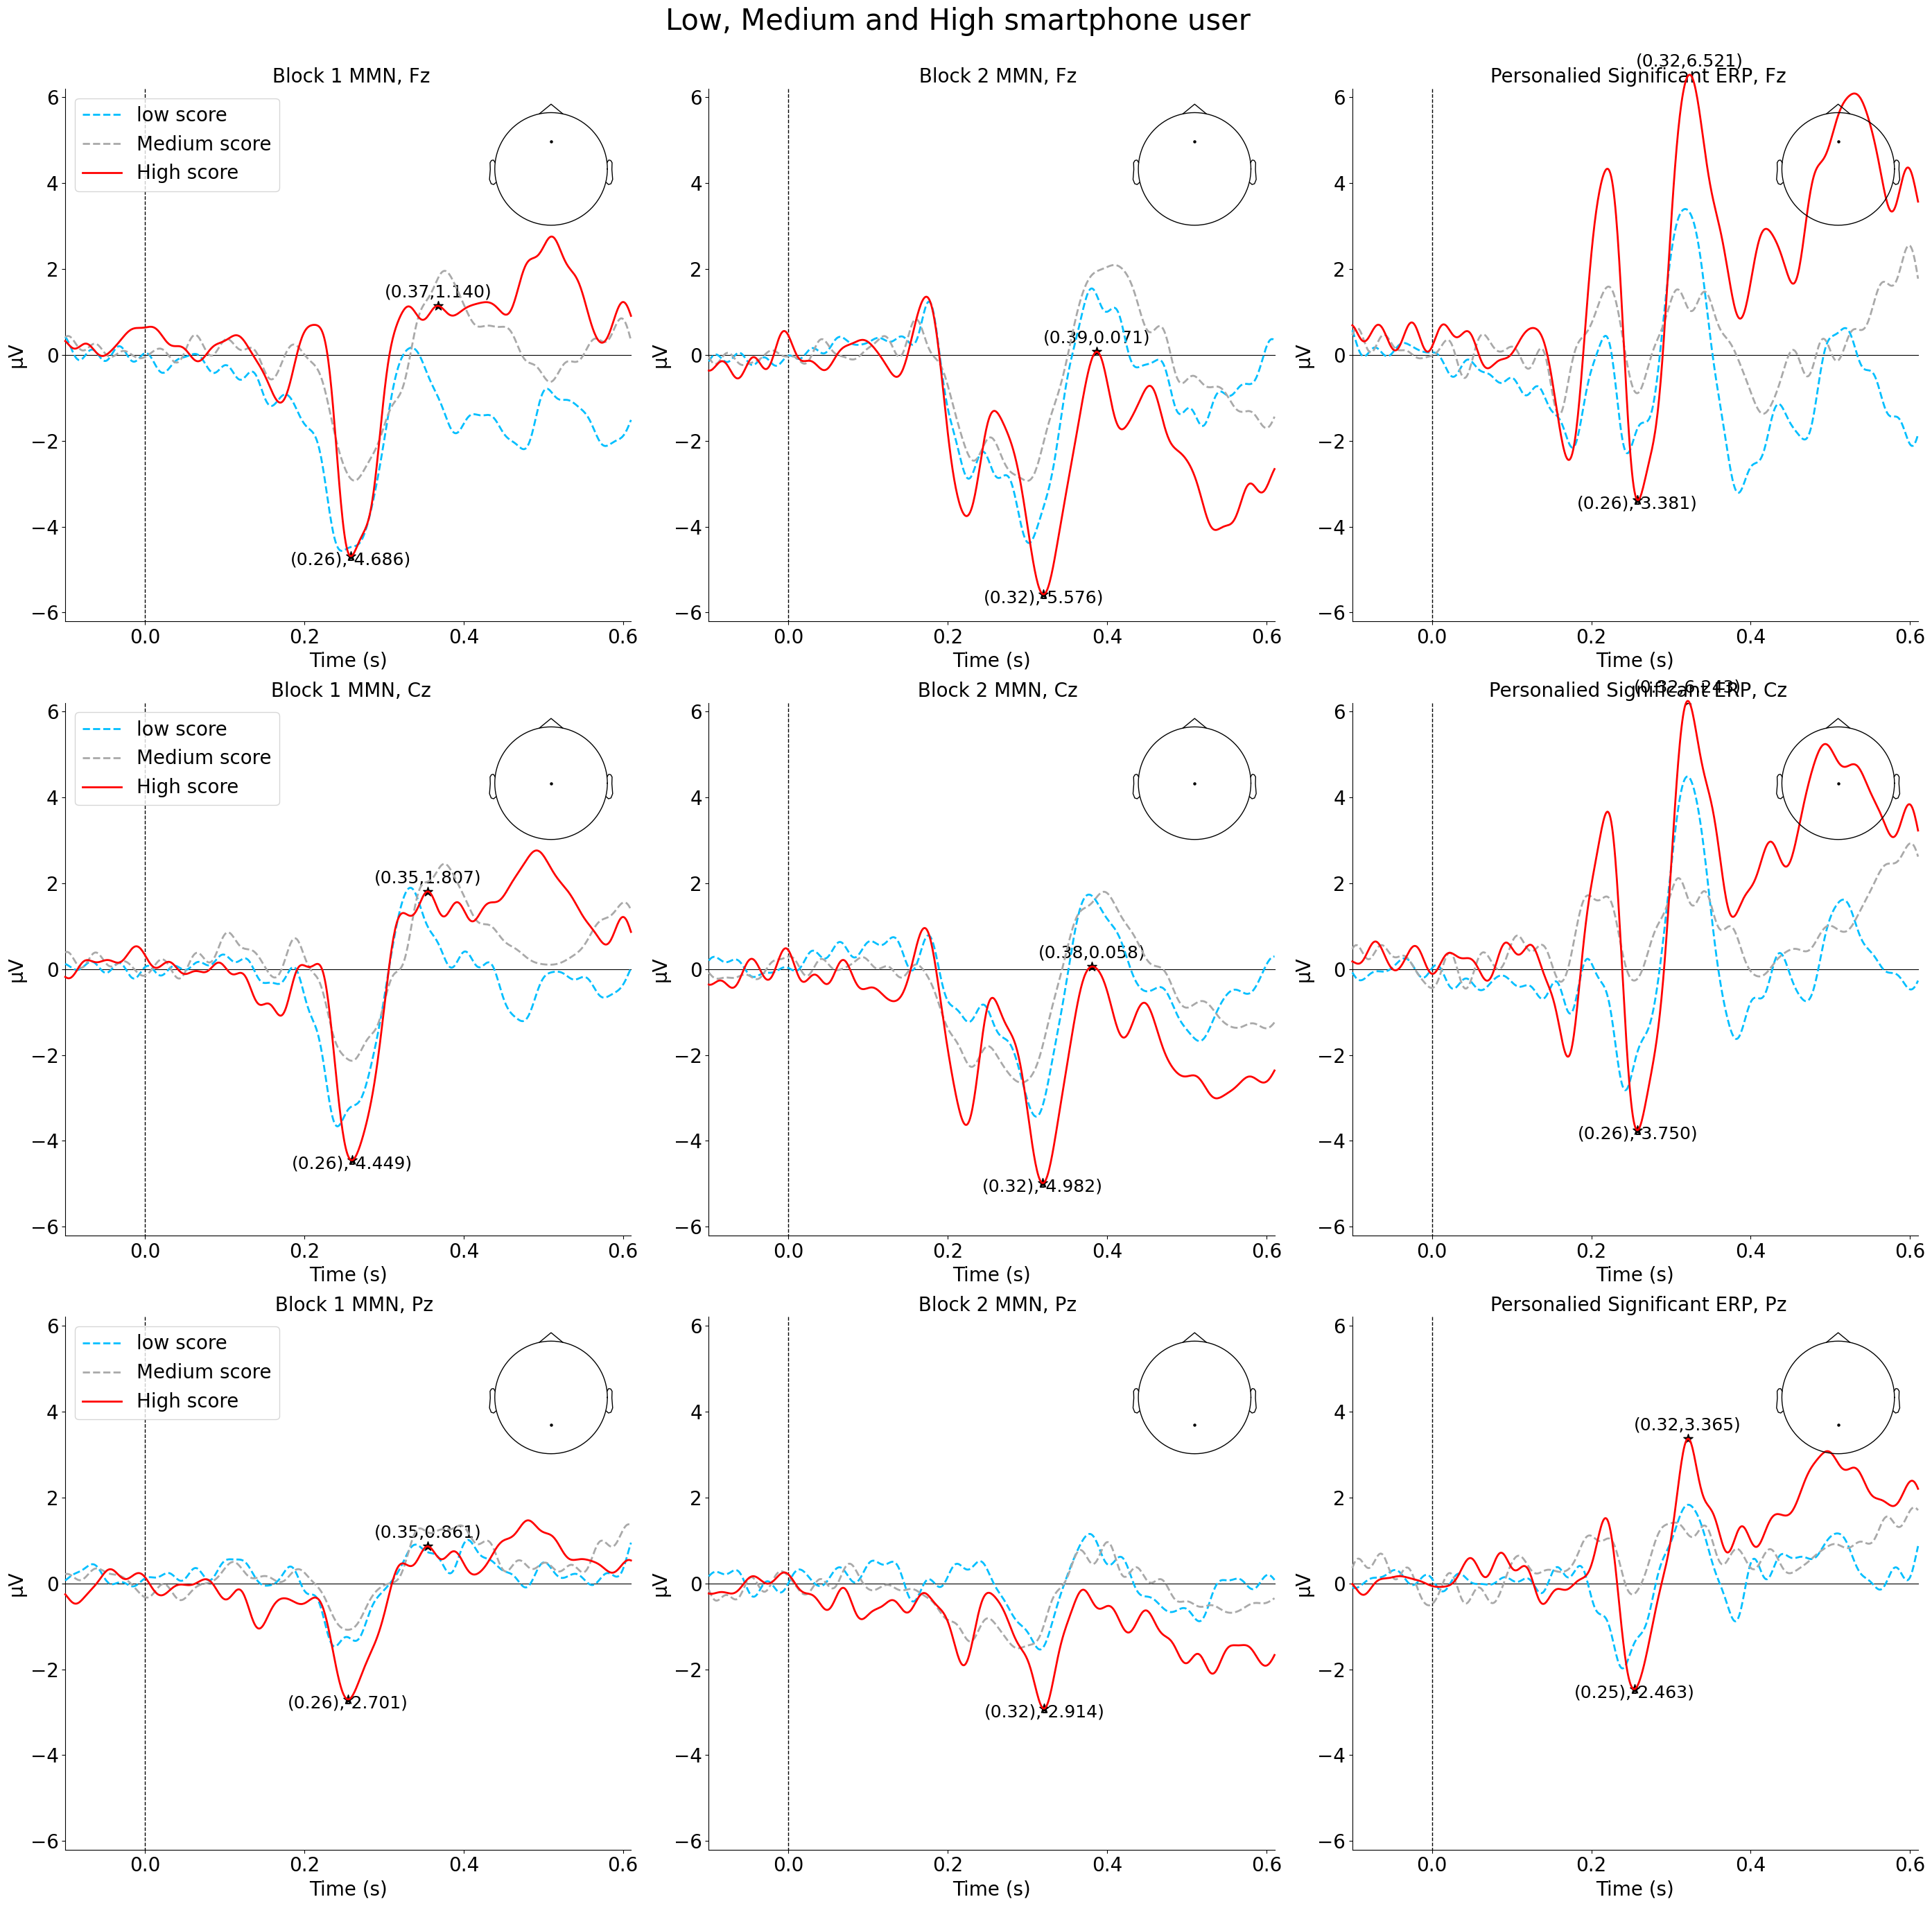

In [24]:
# PS ERp 
# Define the start and end time for the window
start_time = -0.1  # Start of time window in seconds
end_time = 0.61    # End of time window in seconds


# ### B1 MMN for all the categories
evokeds = {'low score': low_sub_D_B1_MMN_erp,
           'Medium score': med_sub_D_B1_MMN_erp,
           'High score': high_sub_D_B1_MMN_erp,
           }
stylesdict ={'low score': {"linewidth": 2,"linestyle":'--'},
             'Medium score': {"linewidth": 2,"linestyle":'--'},
             'High score' : {"linewidth": 2,"linestyle":'solid'},
             }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)

# Plot the evoked responses
fig,axs = plt.subplots(3,3,figsize=(28, 28))  # Create a figure and axis

mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0,0],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show = False,title=" Block 1 MMN, " + str(picks[0]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1,0],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title=" Block 1 MMN, " + str(picks[1]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2,0],ylim =dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title="  Block 1 MMN, " + str(picks[2]))

plot_pos_peak(laten_data['High score']['Fz +(Latency (s),Amplitude (µV))'],axs[0,0])
plot_neg_peak(laten_data['High score']['Fz- (Latency (s),Amplitude (µV))'],axs[0,0])
plot_pos_peak(laten_data['High score']['Cz +(Latency (s),Amplitude (µV))'],axs[1,0])
plot_neg_peak(laten_data['High score']['Cz- (Latency (s),Amplitude (µV))'],axs[1,0])
plot_pos_peak(laten_data['High score']['Pz +(Latency (s),Amplitude (µV))'],axs[2,0])
plot_neg_peak(laten_data['High score']['Pz- (Latency (s),Amplitude (µV))'],axs[2,0])



# ### B2 MMN for all the categories
evokeds = {'low score': low_sub_D_B2_MMN_erp,
           'Medium score': med_sub_D_B2_MMN_erp,
           'High score': high_sub_D_B2_MMN_erp,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)


mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0,1],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show = False,legend=False,title="  Block 2 MMN, " + str(picks[0]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1,1],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title="  Block 2 MMN, " + str(picks[1]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2,1],ylim =dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title="  Block 2 MMN, " + str(picks[2]))

plot_pos_peak(laten_data['High score']['Fz +(Latency (s),Amplitude (µV))'],axs[0,1])
plot_neg_peak(laten_data['High score']['Fz- (Latency (s),Amplitude (µV))'],axs[0,1])
plot_pos_peak(laten_data['High score']['Cz +(Latency (s),Amplitude (µV))'],axs[1,1])
plot_neg_peak(laten_data['High score']['Cz- (Latency (s),Amplitude (µV))'],axs[1,1])
plot_pos_peak(laten_data['High score']['Pz +(Latency (s),Amplitude (µV))'],axs[2,1])
plot_neg_peak(laten_data['High score']['Pz- (Latency (s),Amplitude (µV))'],axs[2,1])



# ### Personalized siginificant ERP for all the categories
evokeds = {'low score': low_sub_D_Personalized_MMN_erp,
           'Medium score': med_sub_D_Personalized_MMN_erp,
           'High score': high_sub_D_Personalized_MMN_erp,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

laten_data = get_latency_amp_each_chn(evokeds_subset,tmin=.2,tmax =.4, channels=picks)
print(laten_data )
latency_amps.append(laten_data)


mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[0],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[0,2],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show = False,legend=False,title=" Personalied Significant ERP, " + str(picks[0]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[1,2],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title=" Personalied Significant ERP, " + str(picks[1]))
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[2],colors = ['deepskyblue',"darkgray","red"],
                                   styles=stylesdict, combine='mean',axes=axs[2,2],ylim = dict(eeg=[-6.2,6.2]),
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,legend=False,title=" Personalied Significant ERP, " + str(picks[2]))

plot_pos_peak(laten_data['High score']['Fz +(Latency (s),Amplitude (µV))'],axs[0,2])
plot_neg_peak(laten_data['High score']['Fz- (Latency (s),Amplitude (µV))'],axs[0,2])
plot_pos_peak(laten_data['High score']['Cz +(Latency (s),Amplitude (µV))'],axs[1,2])
plot_neg_peak(laten_data['High score']['Cz- (Latency (s),Amplitude (µV))'],axs[1,2])
plot_pos_peak(laten_data['High score']['Pz +(Latency (s),Amplitude (µV))'],axs[2,2])
plot_neg_peak(laten_data['High score']['Pz- (Latency (s),Amplitude (µV))'],axs[2,2])


# Add an overall title for the whole plot
fig.suptitle('Low, Medium and High smartphone user  ', fontsize=30)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size 
    'legend.fontsize': 20,   # Legend font size
})
plt.show()